# Constant antibiotic environments and community-size controls

This notebook implements the constant-environment simulations used to establish the baseline plasmid population dynamics. The same experimentally parameterized consumer-resource model is used throughout the repository; only the antibiotic control vector, the initial plasmid state, and the community composition are changed. The analyses begin with controlled monoculture simulations of plasmid-bearing and plasmid-free subpopulations, then extend the same framework to dose-response assays in individual strains, complete communities, and randomly sampled communities.


In [308]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [309]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Axis labels
    "axes.labelsize": 16,

    # Plot titles
    "axes.titlesize": 16,
    "figure.titlesize": 16,

    # Legends
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,

    # General text
    "font.size": 14,

    # Optional: make saved figures cleaner
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

plt.rcParams.update({
    "axes.linewidth": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "legend.frameon": False,
})

## Simulation Parameters

In [310]:
extinction_threshold = 1e5

num_days = 32
B_initial = 1e6

M_fixed = 5
num_communities_M10 = 1000
num_communities_per_size = 100
max_total_simulations = 1000

Amin = 0.0
Amax = 512.0

A_values = [0] + [2**i for i in range(-2, 15)]

## Repository paths and simulation parameters

The notebook expects the repository to contain the model code, parameter table, saved simulation objects, and generated figures. Simulation outputs are written to `runs/` and figures to `figures/`, so previously completed simulations can be reloaded rather than recomputed.


In [311]:
PROJECT_ROOT = Path.cwd()

codePath = PROJECT_ROOT / 'code'
dataPath = PROJECT_ROOT / 'data'
envPath = PROJECT_ROOT / 'env'


runPath = PROJECT_ROOT / f"runs/A{Amax:g}_T{num_days:g}"
figPath = PROJECT_ROOT / f"figures/A{Amax:g}_T{num_days:g}"

for p in [runPath, figPath]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('codePath     =', codePath)
print('dataPath     =', dataPath)
print('runPath      =', runPath)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT
codePath     = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/code
dataPath     = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/data
runPath      = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32


In [312]:

REPO=False
if REPO:
    repo_url = 'https://github.com/ccg-esb-lab/plasmidNoise.git'
    repo_name = 'plasmidNoise'

    if not Path(repo_name).exists():
        !git clone {repo_url}

    PROJECT_ROOT = Path(repo_name).resolve()
    codePath = PROJECT_ROOT / 'code'
    dataPath = PROJECT_ROOT / 'data'
    envPath = PROJECT_ROOT / 'env'


    runPath = PROJECT_ROOT / f"runs/A{Amax:g}_T{num_days_stochastic:g}"
    figPath = PROJECT_ROOT / f"figures/A{Amax:g}_T{num_days_stochastic:g}"

    for p in [runPath, figPath]:
        p.mkdir(parents=True, exist_ok=True)

if str(codePath) not in sys.path:
    sys.path.insert(0, str(codePath))

print('Files in codePath:')
for p in sorted(codePath.glob('*.py')):
    print('  ', p.name)


Files in codePath:
   plasmidNoise_model.py
   plasmidNoise_plotter.py


## Model modules

The simulations use the population-dynamics routines in `plasmidNoise_model.py` and the shared plotting utilities in `plasmidNoise_plotter.py`. Keeping model and plotting functions in separate modules makes the notebook a reproducible analysis script rather than the primary location of the model implementation.


In [313]:
import plasmidNoise_model as pn
import plasmidNoise_plotter as pp


## Parameterized plasmid-host library

The parameter table contains strain-specific growth parameters, antibiotic susceptibility, segregational loss, and conjugation permissiveness for plasmid-bearing and plasmid-free states. These experimentally derived differences define the host-dependent fitness landscape over which the plasmid is maintained, lost, or transferred.


In [314]:
params_csv = dataPath / 'pOXA48_model_params.csv'
model_params = pn.load_parameter_table(params_csv)

print(model_params.shape)
model_params.head()


(50, 20)


,strain,display_name,species,color,r_p,affinity_p,k_star_p,r_0,affinity_0,k_star_0,lambda_loss,gamma,Km_p,Vmax_p,alpha_p,k_p,Km_0,Vmax_0,alpha_0,k_0
0,C001,PF_EC01,E,#d60000,984410100.0,4.900000e-10,0.000488,877563800.0,5.280000e-10,0.000244,0.02,0.0,1.0,4.900000e-10,1.000000e-12,0.015625,1.0,5.280000e-10,1.000000e-10,0.03125
1,C002,PF_EC02,E,#018700,550386500.0,7.600000e-10,0.062500,678608700.0,6.650000e-10,0.000244,0.02,0.0,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.650000e-10,1.000000e-10,0.03125
2,C006,PF_EC03,E,#b500ff,890018480.0,7.600000e-10,0.062500,815145500.0,6.540000e-10,0.000122,0.02,0.0,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.540000e-10,1.000000e-10,0.06250
3,C011,PF_EC04,E,#05acc6,776372125.0,8.370000e-10,0.000488,770241720.0,6.580000e-10,0.000244,0.02,0.0,1.0,8.370000e-10,1.000000e-12,0.015625,1.0,6.580000e-10,1.000000e-10,0.03125
4,C012,PF_EC05,E,#97ff00,772746800.0,6.300000e-10,0.062500,641598800.0,7.830000e-10,0.000122,0.02,0.0,1.0,6.300000e-10,1.000000e-12,0.000122,1.0,7.830000e-10,1.000000e-10,0.06250


In [315]:
selected_strains = [
    'K213',
    'K225',
    'K038',
    'K177',
    'C201',
    'C324',
    'K216',
    'K112',
    'K037',
    'K253',
    'K209',
    'K248',
    'C063',
    'C107',
    'C286',
    'C002',
    'C006',
    'C022',
    'C247',
    'C290'
]

model_params_filtered = model_params[
    model_params["strain"].isin(selected_strains)
].copy()

strain_list = sorted(model_params_filtered["strain"].unique())

print("Number of selected strains:", len(strain_list))
print(strain_list)

display(model_params_filtered)
#model_params=model_params_filtered.copy()


Number of selected strains: 20
['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324', 'K037', 'K038', 'K112', 'K177', 'K209', 'K213', 'K216', 'K225', 'K248', 'K253']


,strain,display_name,species,color,r_p,affinity_p,k_star_p,r_0,affinity_0,k_star_0,lambda_loss,gamma,Km_p,Vmax_p,alpha_p,k_p,Km_0,Vmax_0,alpha_0,k_0
1,C002,PF_EC02,E,#018700,5.503865e+08,7.600000e-10,0.062500,6.786087e+08,6.650000e-10,0.000244,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.650000e-10,1.000000e-10,0.031250
2,C006,PF_EC03,E,#b500ff,8.900185e+08,7.600000e-10,0.062500,8.151455e+08,6.540000e-10,0.000122,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.540000e-10,1.000000e-10,0.062500
6,C022,PF_EC07,E,#ff8ec8,1.039553e+09,3.790000e-10,0.062500,1.013229e+09,4.150000e-10,0.000488,0.02,0.000000e+00,1.0,3.790000e-10,1.000000e-12,0.000122,1.0,4.150000e-10,1.000000e-10,0.015625
9,C063,PF_EC10,E,#afa5ff,1.071282e+09,5.660000e-10,0.031250,8.472142e+08,7.370000e-10,0.000488,0.02,8.628693e-13,1.0,5.660000e-10,1.000000e-12,0.000244,1.0,7.370000e-10,1.000000e-10,0.015625
11,C107,PF_EC12,E,#9a6900,9.093514e+08,5.190000e-10,0.062500,9.767934e+08,4.810000e-10,0.000488,0.02,7.479731e-12,1.0,5.190000e-10,1.000000e-12,0.000122,1.0,4.810000e-10,1.000000e-10,0.015625
15,C201,PF_EC16,E,#c86e66,1.121715e+09,4.910000e-10,0.062500,1.040166e+09,5.550000e-10,0.000244,0.02,6.852673e-11,1.0,4.910000e-10,1.000000e-12,0.000122,1.0,5.550000e-10,1.000000e-10,0.031250
18,C247,PF_EC19,E,#a877ac,9.811784e+08,6.080000e-10,0.062500,9.423508e+08,6.200000e-10,0.000122,0.02,0.000000e+00,1.0,6.080000e-10,1.000000e-12,0.000122,1.0,6.200000e-10,1.000000e-10,0.062500
20,C286,PF_EC21,E,#f4bfb1,1.020861e+09,5.550000e-10,0.062500,8.386482e+08,4.900000e-10,0.000488,0.02,2.790403e-12,1.0,5.550000e-10,1.000000e-12,0.000122,1.0,4.900000e-10,1.000000e-10,0.015625
21,C290,PF_EC22,E,#ff28fd,9.735538e+08,6.150000e-10,0.062500,9.885546e+08,6.620000e-10,0.000122,0.02,0.000000e+00,1.0,6.150000e-10,1.000000e-12,0.000122,1.0,6.620000e-10,1.000000e-10,0.062500
24,C324,PF_EC25,E,#ff6200,9.236833e+08,6.780000e-10,0.003906,1.003584e+09,5.470000e-10,0.000977,0.02,8.950370e-12,1.0,6.780000e-10,1.000000e-12,0.001953,1.0,5.470000e-10,1.000000e-10,0.007812


In [316]:
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_strain_color_map(
    strains,
    model_params=None,
    strain_col="strain",
    color_col="color",
):
    """
    Build a strain -> color map.

    Priority:
    1. Use model_params[color_col] if available.
    2. Fall back to matplotlib default colors for missing strains.

    Parameters
    ----------
    strains : list-like
        Strain names to color.

    model_params : pandas.DataFrame, optional
        Parameter table containing strain and color columns.

    strain_col : str
        Column name with strain IDs.

    color_col : str
        Column name with strain colors.

    Returns
    -------
    dict
        strain -> color
    """

    strains = sorted([str(s) for s in strains])

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    strain_color_map = {
        strain: default_colors[i % len(default_colors)]
        for i, strain in enumerate(strains)
    }

    if model_params is None:
        return strain_color_map

    if strain_col not in model_params.columns:
        return strain_color_map

    if color_col not in model_params.columns:
        return strain_color_map

    color_df = (
        model_params[[strain_col, color_col]]
        .dropna()
        .copy()
    )

    color_df[strain_col] = color_df[strain_col].astype(str)

    for strain in strains:
        colors = (
            color_df.loc[color_df[strain_col] == strain, color_col]
            .dropna()
            .astype(str)
            .unique()
        )

        if len(colors) > 0:
            strain_color_map[strain] = colors[0]

    return strain_color_map


## Shared helpers for endpoint summaries and plotting

The following helper functions extract endpoint densities, plasmid fractions, and strain-level composition from saved simulation objects. The same functions are used for monocultures and multistrain communities, allowing constant, periodic, and stochastic environments to be compared within a common output format.


In [317]:
# Local plotting helpers for Figure 2-style examples.
# Later we can move these into plasmidNoise_plotter.py.

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def plot_single_transfer_dynamics(
    result,
    *,
    title=None,
    save_path=None,
    density_ylim=None,
    relative_ylim=(-2, 102),
):
    """
    Plot one simulation with three panels:
    1. Resource and antibiotic
    2. Absolute densities
    3. Relative abundance of Bp and Bempty

    Assumes a single-transfer simulation.
    """
    tr = result.transfers[0]
    t = tr["t"]
    y = tr["y"]
    n = len(result.members)

    R = y[0, :]
    A = y[1, :]
    Bp = y[2 : 2 + n, :].sum(axis=0)
    Bempty = y[2 + n : 2 + 2 * n, :].sum(axis=0)
    Btotal = Bp + Bempty

    Bp_rel = np.divide(Bp, Btotal, out=np.full_like(Bp, np.nan), where=Btotal > 0) * 100
    Bempty_rel = np.divide(Bempty, Btotal, out=np.full_like(Bempty, np.nan), where=Btotal > 0) * 100

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    # Panel 1: environment
    axes[0].plot(t, R, label="Resource")
    axes[0].plot(t, A, label="Antibiotic")
    axes[0].set_xlabel("Time (hours)")
    axes[0].set_ylabel("Concentration")
    axes[0].legend(frameon=False)

    # Panel 2: densitiese
    axes[1].plot(t, Bp, '-',  color='#3784BA',label=r"$B_p$")
    axes[1].plot(t, Bempty, '--', color='#3784BA',label=r"$B_\emptyset$")
    axes[1].plot(t, Btotal, linestyle="-", color='k', label=r"$B_{total}$")
    axes[1].set_xlabel("Time (hours)")
    axes[1].set_ylabel("Density")
    if density_ylim is not None:
        axes[1].set_ylim(*density_ylim)
    axes[1].legend(frameon=False)

    # Panel 3: relative abundance
    axes[2].plot(t, Bp_rel, '-',  color='#3784BA', label=r"$B_p$")
    axes[2].plot(t, Bempty_rel, '--', color='#3784BA', label=r"$B_\emptyset$")
    axes[2].set_xlabel("Time (hours)")
    axes[2].set_ylabel("Relative abundance (%)")
    axes[2].set_ylim(*relative_ylim)
    axes[2].legend(frameon=False)

    if title is not None:
        fig.suptitle(title, y=1.05)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes


def plot_drug_response_dynamics(
    loaded_results,
    *,
    save_path=None,
    density_ylim=None,
):
    """
    Plot dose-response simulations as one row of density panels.
    Each result should be a single-transfer simulation.
    """
    n_panels = len(loaded_results)
    fig, axes = plt.subplots(1, n_panels, figsize=(2.4 * n_panels, 3.0), sharey=True)

    if n_panels == 1:
        axes = [axes]

    for ax, result in zip(axes, loaded_results):
        tr = result.transfers[0]
        t = tr["t"]
        y = tr["y"]
        n = len(result.members)

        A0 = tr["A_initial"]
        Bp = y[2 : 2 + n, :].sum(axis=0)
        Bempty = y[2 + n : 2 + 2 * n, :].sum(axis=0)
        Btotal = Bp + Bempty

        ax.plot(t, Bp, '-', label=r"$B_p$", color='#FF7F0F')
        ax.plot(t, Bempty, '--', color='#FF7F0F', label=r"$B_\emptyset$")
        ax.plot(t, Btotal, linestyle="-", color="k", label=r"$B_{total}$")

        ax.set_title(f"A={A0:g}")
        ax.set_xlabel("Time (hours)")

        if density_ylim is not None:
            ax.set_ylim(*density_ylim)

    axes[0].set_ylabel("Density")
    axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes


## Single-strain initial-condition controls

These simulations isolate the basic asymmetry between plasmid-bearing cells, $B_p$, and plasmid-free cells, $B_\emptyset$. Plasmid-free cells can be generated from $B_p$ by segregational loss, but $B_p$ cannot reappear after plasmid loss unless plasmid-bearing donors remain. These controls define the mechanism used throughout the paper: antibiotic exposure favors plasmid-bearing cells, whereas drug-free growth can erode the plasmid-bearing reservoir.


In [318]:
# Simulation settings for the initial-condition controls.

figure_run_path = runPath / "figure2_initial_conditions"
figure_run_path.mkdir(parents=True, exist_ok=True)

figure_save_path = figPath / "figure2_initial_conditions"
figure_save_path.mkdir(parents=True, exist_ok=True)


B_initial = 1e6

this_strain=12

base_config = pn.SimulationConfig(
    season_duration=24.0,
    points_per_season=241,
    R0=1.0,
    B0_total=B_initial,
    dilution=1.0,              # irrelevant for one-transfer examples
    extinction_threshold=extinction_threshold,
    solver_method="LSODA",
    uptake_mode="monod",
)


### Drug-free environment, initially plasmid-bearing

The population is initialized as $B_p=B_0$ and $B_\emptyset=0$ with no antibiotic. This control tests whether plasmid carriage is maintained when the plasmid provides no selective benefit.


In [319]:
# Use one strain for the basic plasmid population model.
# Change this manually if you want a specific isolate.
member = model_params["strain"].iloc[this_strain]
members = [member]
print("Using member:", member)


Using member: C115


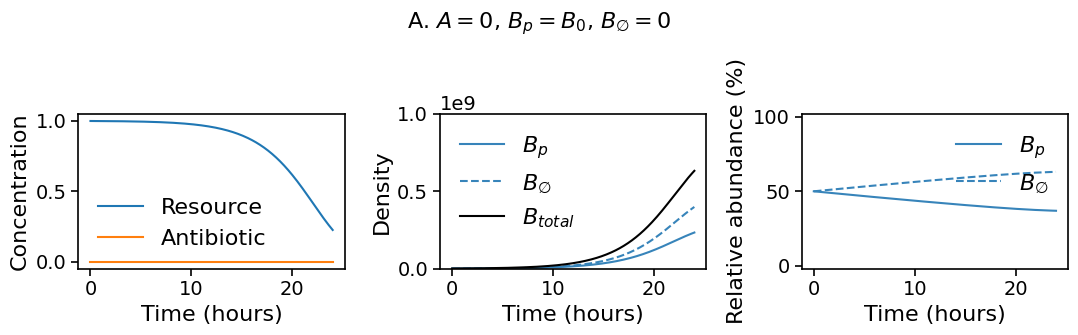

In [320]:
# Figure 2A
# A = 0
# Initial condition: Bp = B0, Bempty = 0

config_A = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "initial_plasmid_fraction": 0.5,
    }
)

environment_A = pn.make_constant_environment(n_transfers=5, concentration=0.0)

result_A = pn.simulate_serial_transfers(
    model_params,
    members=members,
    environment=environment_A,
    config=config_A,
    run_id=f"fig2A_{member}_A0_Bp_init",
    metadata={
        "figure": "Figure 2A",
        "description": "No antibiotic; initially plasmid-bearing population",
    },
)

save_file_A = pn.save_simulation(
    result_A,
    figure_run_path / f"{result_A.run_id}.pkl.gz",
)

loaded_A = pn.load_simulation(save_file_A)

fig_A, axes_A = plot_single_transfer_dynamics(
    loaded_A,
    title=r"A. $A=0$, $B_p=B_0$, $B_\emptyset=0$",
    density_ylim=[0, 1e9],
    save_path=figure_save_path / "fig2A_A0_Bp_init.png",
)


### Drug-free environment, initially plasmid-free

The population is initialized as $B_p=0$ and $B_\emptyset=B_0$ with no antibiotic. Because no plasmid-bearing donors are present, this control defines the growth trajectory of the plasmid-free state.


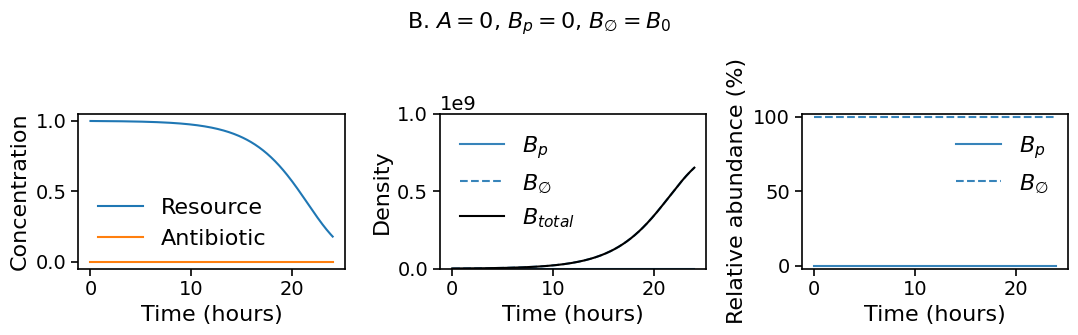

In [321]:
# Figure 2B
# A = 0
# Initial condition: Bp = 0, Bempty = B0

config_B = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "initial_plasmid_fraction": 0.0,
    }
)

environment_B = pn.make_constant_environment(n_transfers=1, concentration=0.0)

result_B = pn.simulate_serial_transfers(
    model_params,
    members=members,
    environment=environment_B,
    config=config_B,
    run_id=f"fig2B_{member}_A0_Bempty_init",
    metadata={
        "figure": "Figure 2B",
        "description": "No antibiotic; initially plasmid-free population",
    },
)

save_file_B = pn.save_simulation(
    result_B,
    figure_run_path / f"{result_B.run_id}.pkl.gz",
)

loaded_B = pn.load_simulation(save_file_B)

fig_B, axes_B = plot_single_transfer_dynamics(
    loaded_B,
    title=r"B. $A=0$, $B_p=0$, $B_\emptyset=B_0$",
    density_ylim=[0, 1e9],
    save_path=figure_save_path / "fig2B_A0_Bempty_init.png",
)


### Antibiotic present, initially plasmid-bearing

The population is initialized as $B_p=B_0$ and $B_\emptyset=0$ under antibiotic exposure. This simulation tests whether plasmid-mediated resistance is sufficient to maintain population growth despite ongoing segregational loss.


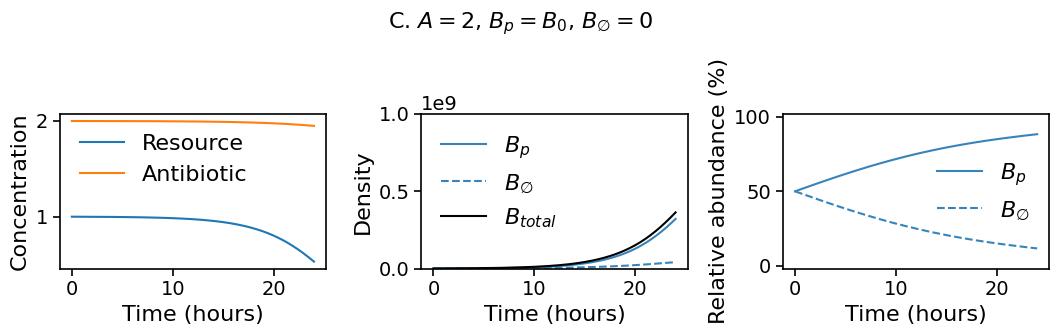

In [322]:
# Figure 2C
# A = 1
# Initial condition: Bp = B0, Bempty = 0

config_C = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "initial_plasmid_fraction": 0.5,
    }
)

this_Amax=2

environment_C = pn.make_constant_environment(n_transfers=1, concentration=this_Amax)

result_C = pn.simulate_serial_transfers(
    model_params,
    members=members,
    environment=environment_C,
    config=config_C,
    run_id=f"fig2C_{member}_A1_Bp_init",
    metadata={
        "figure": "Figure 2C",
        "description": "Antibiotic present; initially plasmid-bearing population",
    },
)

save_file_C = pn.save_simulation(
    result_C,
    figure_run_path / f"{result_C.run_id}.pkl.gz",
)

loaded_C = pn.load_simulation(save_file_C)

fig_C, axes_C = plot_single_transfer_dynamics(
    loaded_C,
    title=r"C. $A=%s$, $B_p=B_0$, $B_\emptyset=0$"%this_Amax,
    density_ylim=[0, 1e9],
    save_path=figure_save_path / "fig2C_A1_Bp_init.png",
)


### Antibiotic present, initially plasmid-free

The population is initialized as $B_p=0$ and $B_\emptyset=B_0$ under antibiotic exposure. This control tests whether plasmid-free cells collapse when no resistant subpopulation is available to rescue growth.


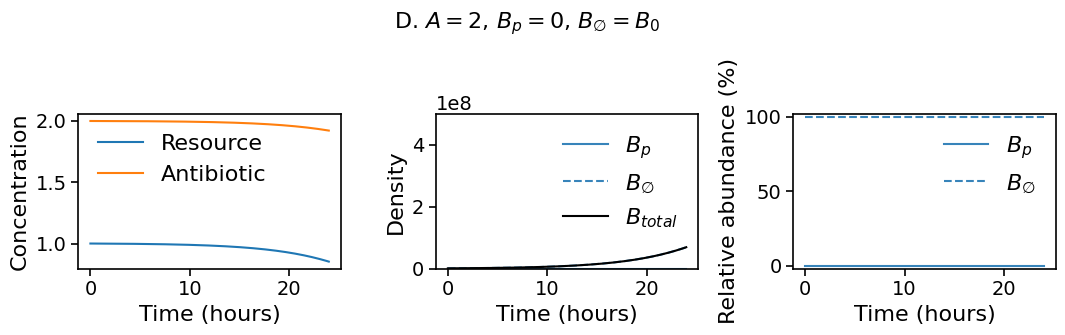

In [323]:
# Figure 2D
# A = 1
# Initial condition: Bp = 0, Bempty = B0

config_D = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "initial_plasmid_fraction": 0.0,
    }
)

environment_D = pn.make_constant_environment(n_transfers=1, concentration=this_Amax)

result_D = pn.simulate_serial_transfers(
    model_params,
    members=members,
    environment=environment_D,
    config=config_D,
    run_id=f"fig2D_{member}_A1_Bempty_init",
    metadata={
        "figure": "Figure 2D",
        "description": "Antibiotic present; initially plasmid-free population",
    },
)

save_file_D = pn.save_simulation(
    result_D,
    figure_run_path / f"{result_D.run_id}.pkl.gz",
)

loaded_D = pn.load_simulation(save_file_D)

fig_D, axes_D = plot_single_transfer_dynamics(
    loaded_D,
    title=r"D. $A=%s$, $B_p=0$, $B_\emptyset=B_0$"%this_Amax,
    density_ylim=[0, 5e8],
    save_path=figure_save_path / "fig2D_A1_Bempty_init.png",
)


## Single-strain dose-response across antibiotic concentrations

The initially plasmid-bearing population is simulated across a range of antibiotic concentrations. Endpoint densities of $B_p$, $B_\emptyset$, and $B_{\mathrm{total}}$ identify the concentration range where plasmid carriage changes population outcome and the high-drug regime where resistance is insufficient to prevent collapse.


In [324]:
def make_log2_dose_positions(doses):
    """
    Convert antibiotic doses to log2-spaced positions.

    A0 = 0 is placed one step to the left of the smallest positive dose.
    """

    doses = pd.Series(doses).astype(float)

    positive_doses = doses[doses > 0]

    if len(positive_doses) == 0:
        raise ValueError("At least one positive dose is needed for log2 positioning.")

    min_positive = positive_doses.min()
    zero_position = np.log2(min_positive) - 1

    positions = pd.Series(index=doses.index, dtype=float)

    positions.loc[doses > 0] = np.log2(doses.loc[doses > 0])
    positions.loc[doses == 0] = zero_position

    tick_doses = sorted(doses.unique())
    tick_positions = []

    for d in tick_doses:
        if d > 0:
            tick_positions.append(np.log2(d))
        else:
            tick_positions.append(zero_position)

    return positions.to_numpy(), tick_positions, tick_doses


def apply_log2_dose_axis(ax, doses):
    """
    Apply log2-spaced x-axis ticks while labeling with the original dose values.
    """

    _, tick_positions, tick_doses = make_log2_dose_positions(doses)

    tick_labels = [
        "0" if d == 0 else f"{d:g}"
        for d in tick_doses
    ]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_xlabel("Antibiotic concentration (ug/mL)")


def apply_log2_dose_axis(ax, doses):
    """
    Apply log2 dose tick positions and labels to an axis.
    """

    _, tick_positions, tick_labels = make_log2_dose_positions(doses)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        tick_labels,
        rotation=45,
        ha="right",
    )

    ax.set_xlim(
        min(tick_positions) - 0.5,
        max(tick_positions) + 0.5,
    )


    ax.set_xlabel("Antibiotic concentration (ug/mL)")


In [325]:
def add_log2_dose_axis(ax, doses, zero_label="0"):
    """
    Format x-axis as log2 antibiotic concentration while keeping A=0.

    A=0 is placed one tick before the lowest positive log2 dose.
    Positive doses are plotted as log2(A).
    """

    doses = np.array(sorted(pd.Series(doses).dropna().unique()), dtype=float)

    positive_doses = doses[doses > 0]

    if len(positive_doses) == 0:
        raise ValueError("Need at least one positive dose for log2 axis.")

    log2_positive = np.log2(positive_doses)

    zero_position = log2_positive.min() - 1

    tick_positions = [zero_position] + list(log2_positive)
    tick_labels = [zero_label] + [f"{d:g}" for d in positive_doses]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")

    ax.set_xlabel("Initial antibiotic concentration")
    ax.set_xlim(zero_position - 0.5, log2_positive.max() + 0.5)

    return zero_position


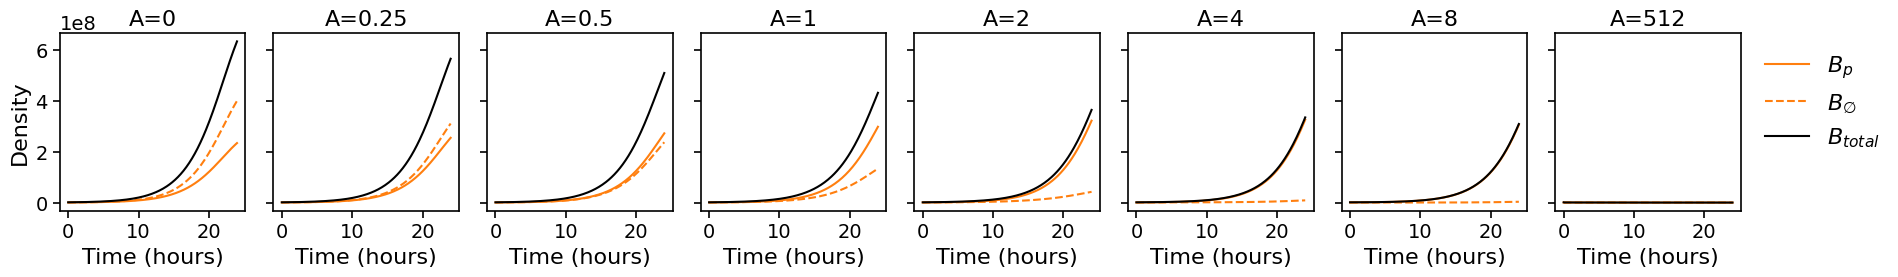

In [326]:
# Figure 2E
# Drug-response experiment under increasing initial antibiotic concentrations.
# Here we start with Bp = B0, Bempty = 0 for all doses.


config_E = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "initial_plasmid_fraction": 0.5
    }
)

loaded_E_results = []

for A0 in A_values[0:7] + [A_values[12]]:
    environment_E = pn.make_constant_environment(n_transfers=1, concentration=A0)

    result_E = pn.simulate_serial_transfers(
        model_params,
        members=members,
        environment=environment_E,
        config=config_E,
        run_id=f"fig2E_{member}_A{A0:g}_Bp_init",
        metadata={
            "figure": "Figure 2E",
            "description": "Dose-response experiment; initially plasmid-bearing population",
            "A0": A0,
        },
    )

    save_file_E = pn.save_simulation(
        result_E,
        figure_run_path / f"{result_E.run_id}.pkl.gz",
    )

    loaded_E = pn.load_simulation(save_file_E)
    loaded_E_results.append(loaded_E)

fig_E, axes_E = plot_drug_response_dynamics(
    loaded_E_results,
    save_path=figure_save_path / "fig2E_drug_response.png",
)


In [327]:
# Dose-response summary:
# final antibiotic dose vs final density of Bp, Bempty, and Btotal.
#
# This uses the loaded simulations from Cell E:
# loaded_E_results


dose_response_rows = []

for result in loaded_E_results:
    tr = result.transfers[0]
    y = tr["y"]
    n = len(result.members)

    A0 = tr["A_initial"]

    Bp_final = y[2 : 2 + n, -1].sum()
    Bempty_final = y[2 + n : 2 + 2 * n, -1].sum()
    Btotal_final = Bp_final + Bempty_final

    dose_response_rows.append(
        {
            "run_id": result.run_id,
            "A0": A0,
            "Bp_final": Bp_final,
            "Bempty_final": Bempty_final,
            "Btotal_final": Btotal_final,
        }
    )

dose_response_df = pd.DataFrame(dose_response_rows)
dose_response_df = dose_response_df.sort_values("A0").reset_index(drop=True)

summary_file = figure_run_path / "fig2E_dose_response_final_densities.csv"
dose_response_df.to_csv(summary_file, index=False)

display(dose_response_df)
print("Saved summary table to:", summary_file)


,run_id,A0,Bp_final,Bempty_final,Btotal_final
0,fig2E_C115_A0_Bp_init,0.00,2.334158e+08,3.989683e+08,6.323842e+08
1,fig2E_C115_A0.25_Bp_init,0.25,2.540794e+08,3.101694e+08,5.642488e+08
2,fig2E_C115_A0.5_Bp_init,0.50,2.716374e+08,2.367448e+08,5.083822e+08
3,fig2E_C115_A1_Bp_init,1.00,2.974024e+08,1.332217e+08,4.306241e+08
4,fig2E_C115_A2_Bp_init,2.00,3.214198e+08,4.213262e+07,3.635524e+08
5,fig2E_C115_A4_Bp_init,4.00,3.253698e+08,8.734035e+06,3.341038e+08
6,fig2E_C115_A8_Bp_init,8.00,3.051753e+08,3.188513e+06,3.083638e+08
7,fig2E_C115_A512_Bp_init,512.00,2.891826e+03,5.348355e-01,2.892361e+03


Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/figure2_initial_conditions/fig2E_dose_response_final_densities.csv


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T32/figure2_initial_conditions/fig2E_dose_vs_final_density_log2x.png


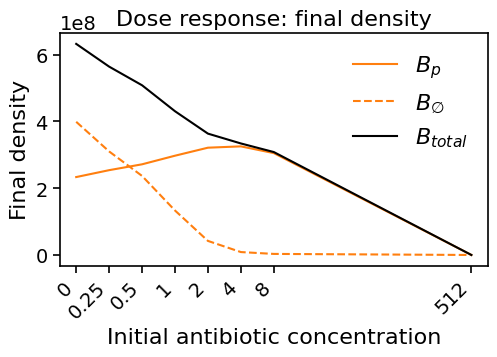

In [328]:
# Plot endpoint densities across the antibiotic dose range.
# Use log2 spacing for positive doses while retaining the no-drug control.

plot_df = dose_response_df.copy()

positive_doses = plot_df.loc[plot_df["A0"] > 0, "A0"]
zero_position = np.log2(positive_doses.min()) - 1

plot_df["A0_log2"] = np.where(
    plot_df["A0"] > 0,
    np.log2(plot_df["A0"]),
    zero_position,
)

fig, ax = plt.subplots(figsize=(5.2, 3.8))

ax.plot(
    plot_df["A0_log2"],
    plot_df["Bp_final"],
    linestyle="-",
    color="#FF7F0F",
    label=r"$B_p$",
)

ax.plot(
    plot_df["A0_log2"],
    plot_df["Bempty_final"],
    linestyle="--",
    color="#FF7F0F",
    label=r"$B_\emptyset$",
)

ax.plot(
    plot_df["A0_log2"],
    plot_df["Btotal_final"],
    linestyle="-",
    color="k",
    label=r"$B_{total}$",
)

add_log2_dose_axis(ax, plot_df["A0"])

ax.set_ylabel("Final density")
ax.set_title("Dose response: final density")
ax.legend(frameon=False)
#ax.set_yscale('log')

fig.tight_layout()

save_file = figure_save_path / "fig2E_dose_vs_final_density_log2x.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [329]:
# Figure 2E-like dose-response experiment for all strains independently.
#
# Each simulation:
#   one strain
#   one transfer
#   initially plasmid-bearing
#   one fixed antibiotic concentration A0

config_E = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "initial_plasmid_fraction": 1.0,
    }
)

all_dose_rows = []
all_loaded_E_results = {}

strain_list = sorted(model_params["strain"].unique())

print("Number of strains:", len(strain_list))
print("Number of doses:", len(A_values))

for strain_id in strain_list:

    members = [strain_id]
    all_loaded_E_results[strain_id] = []

    print("Running/loading strain:", strain_id)

    for A0 in A_values:

        environment_E = pn.make_constant_environment(
            n_transfers=1,
            concentration=A0,
        )

        run_id = f"fig2E_{strain_id}_A{A0:g}_Bp_init"

        save_file_E = figure_run_path / f"{run_id}.pkl.gz"

        if save_file_E.exists():
            loaded_E = pn.load_simulation(save_file_E)

        else:
            result_E = pn.simulate_serial_transfers(
                model_params,
                members=members,
                environment=environment_E,
                config=config_E,
                run_id=run_id,
                metadata={
                    "figure": "Figure 2E",
                    "description": "Dose-response experiment; initially plasmid-bearing population",
                    "strain_id": strain_id,
                    "A0": A0,
                    "initial_plasmid_fraction": 1.0,
                },
            )

            pn.save_simulation(result_E, save_file_E)
            loaded_E = pn.load_simulation(save_file_E)

        all_loaded_E_results[strain_id].append(loaded_E)

        # Extract final densities
        tr = loaded_E.transfers[0]
        y = tr["y"]
        n = len(loaded_E.members)

        Bp_final = y[2 : 2 + n, -1].sum()
        Bempty_final = y[2 + n : 2 + 2 * n, -1].sum()
        Btotal_final = Bp_final + Bempty_final

        if Btotal_final > 0:
            plasmid_fraction = Bp_final / Btotal_final
        else:
            plasmid_fraction = np.nan

        all_dose_rows.append(
            {
                "run_id": run_id,
                "strain": strain_id,
                "A0": A0,
                "Bp_final": Bp_final,
                "Bempty_final": Bempty_final,
                "Btotal_final": Btotal_final,
                "plasmid_fraction": plasmid_fraction,
                "save_file": str(save_file_E),
            }
        )

dose_response_all_strains_df = pd.DataFrame(all_dose_rows)

dose_response_all_strains_df = dose_response_all_strains_df.sort_values(
    ["strain", "A0"]
).reset_index(drop=True)

summary_file = figure_run_path / "fig2E_all_strains_dose_response_final_densities.csv"
dose_response_all_strains_df.to_csv(summary_file, index=False)

display(dose_response_all_strains_df.head())

print("Saved all-strain dose-response summary to:", summary_file)




Number of strains: 50
Number of doses: 18
Running/loading strain: C001
Running/loading strain: C002
Running/loading strain: C006
Running/loading strain: C011
Running/loading strain: C012
Running/loading strain: C021
Running/loading strain: C022
Running/loading strain: C031
Running/loading strain: C051
Running/loading strain: C063
Running/loading strain: C094
Running/loading strain: C107
Running/loading strain: C115
Running/loading strain: C131
Running/loading strain: C141
Running/loading strain: C201
Running/loading strain: C227
Running/loading strain: C232
Running/loading strain: C247
Running/loading strain: C261
Running/loading strain: C286
Running/loading strain: C290
Running/loading strain: C302
Running/loading strain: C309
Running/loading strain: C324
Running/loading strain: K037
Running/loading strain: K038
Running/loading strain: K087
Running/loading strain: K091
Running/loading strain: K112
Running/loading strain: K114
Running/loading strain: K125
Running/loading strain: K141
R

,run_id,strain,A0,Bp_final,Bempty_final,Btotal_final,plasmid_fraction,save_file
0,fig2E_C001_A0_Bp_init,C001,0.00,2.481296e+08,2.645166e+07,2.745812e+08,0.903665,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
1,fig2E_C001_A0.25_Bp_init,C001,0.25,2.282307e+08,2.326744e+07,2.514982e+08,0.907485,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
2,fig2E_C001_A0.5_Bp_init,C001,0.50,2.097743e+08,2.046582e+07,2.302401e+08,0.911111,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
3,fig2E_C001_A1_Bp_init,C001,1.00,1.768696e+08,1.583590e+07,1.927055e+08,0.917823,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
4,fig2E_C001_A2_Bp_init,C001,2.00,1.249122e+08,9.498035e+06,1.344103e+08,0.929336,/content/drive/MyDrive/SYNC_Projects/plasmidNo...


Saved all-strain dose-response summary to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/figure2_initial_conditions/fig2E_all_strains_dose_response_final_densities.csv


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T32/figure2_initial_conditions/fig2E_all_strains_dose_response_with_mean_log2x.png


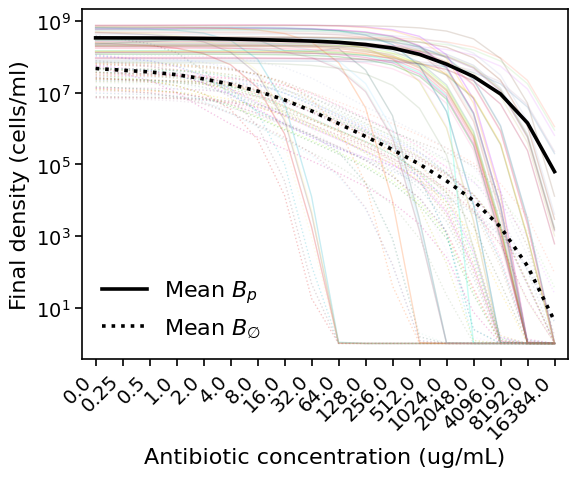

In [330]:
plot_df = dose_response_all_strains_df.copy()

# Use the correct strain column
if "strain" in plot_df.columns:
    strain_col = "strain"
elif "strain_id" in plot_df.columns:
    strain_col = "strain_id"
else:
    raise KeyError("Could not find either 'strain' or 'strain_id' in plot_df.")

plot_df["A0_log2"], _, _ = make_log2_dose_positions(plot_df["A0"])

summary_df = (
    plot_df
    .groupby("A0")
    .agg(
        Bp_mean=("Bp_final", "mean"),
        Bempty_mean=("Bempty_final", "mean"),
        Btotal_mean=("Btotal_final", "mean"),
    )
    .reset_index()
)

summary_df["A0_log2"], _, _ = make_log2_dose_positions(summary_df["A0"])

# Build strain color map
strain_color_map = make_strain_color_map(
    plot_df[strain_col].unique(),
    model_params=model_params,
    strain_col="strain",
    color_col="color",
)

fig, ax = plt.subplots(figsize=(6,5))

alpha_lines = 0.22
linewidth = 1.0
eps = 1.0

for strain_id, sub in plot_df.groupby(strain_col):

    sub = sub.sort_values("A0_log2")
    color = strain_color_map.get(str(strain_id), "gray")

    ax.plot(
        sub["A0_log2"],
        sub["Bp_final"] + eps,
        linestyle="-",
        linewidth=linewidth,
        alpha=alpha_lines,
        color=color,
    )

    ax.plot(
        sub["A0_log2"],
        sub["Bempty_final"] + eps,
        linestyle=":",
        linewidth=linewidth,
        alpha=alpha_lines,
        color=color,
    )

# Mean Bp
ax.plot(
    summary_df["A0_log2"],
    summary_df["Bp_mean"] + eps,
    linestyle="-",
    linewidth=2.6,
    color="black",
    label=r"Mean $B_p$",
)

# Mean Bempty
ax.plot(
    summary_df["A0_log2"],
    summary_df["Bempty_mean"] + eps,
    linestyle=":",
    linewidth=2.6,
    color="black",
    label=r"Mean $B_\emptyset$",
)

apply_log2_dose_axis(ax, plot_df["A0"])

ax.set_yscale("log")
ax.set_ylabel(f"Final density (cells/ml)")

ax.legend(frameon=False)

fig.tight_layout()

save_file = figure_save_path / "fig2E_all_strains_dose_response_with_mean_log2x.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)

## Serial transfers (constant antibiotic environments)

In [331]:
selected_strains = [
    'K213',
    'K225',
    'K038',
    'K177',
    'C201',
    'C324',
    'K216',
    'K112',
    'K037',
    'K253',
    'K209',
    'K248',
    'C063',
    'C107',
    'C286',
    'C002',
    'C006',
    'C022',
    'C247',
    'C290'
]

model_params_filtered = model_params[
    model_params["strain"].isin(selected_strains)
].copy()

strain_list = sorted(model_params_filtered["strain"].unique())

print("Number of selected strains:", len(strain_list))
print(strain_list)

display(model_params_filtered)
model_params=model_params_filtered.copy()


Number of selected strains: 20
['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324', 'K037', 'K038', 'K112', 'K177', 'K209', 'K213', 'K216', 'K225', 'K248', 'K253']


,strain,display_name,species,color,r_p,affinity_p,k_star_p,r_0,affinity_0,k_star_0,lambda_loss,gamma,Km_p,Vmax_p,alpha_p,k_p,Km_0,Vmax_0,alpha_0,k_0
1,C002,PF_EC02,E,#018700,5.503865e+08,7.600000e-10,0.062500,6.786087e+08,6.650000e-10,0.000244,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.650000e-10,1.000000e-10,0.031250
2,C006,PF_EC03,E,#b500ff,8.900185e+08,7.600000e-10,0.062500,8.151455e+08,6.540000e-10,0.000122,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.540000e-10,1.000000e-10,0.062500
6,C022,PF_EC07,E,#ff8ec8,1.039553e+09,3.790000e-10,0.062500,1.013229e+09,4.150000e-10,0.000488,0.02,0.000000e+00,1.0,3.790000e-10,1.000000e-12,0.000122,1.0,4.150000e-10,1.000000e-10,0.015625
9,C063,PF_EC10,E,#afa5ff,1.071282e+09,5.660000e-10,0.031250,8.472142e+08,7.370000e-10,0.000488,0.02,8.628693e-13,1.0,5.660000e-10,1.000000e-12,0.000244,1.0,7.370000e-10,1.000000e-10,0.015625
11,C107,PF_EC12,E,#9a6900,9.093514e+08,5.190000e-10,0.062500,9.767934e+08,4.810000e-10,0.000488,0.02,7.479731e-12,1.0,5.190000e-10,1.000000e-12,0.000122,1.0,4.810000e-10,1.000000e-10,0.015625
15,C201,PF_EC16,E,#c86e66,1.121715e+09,4.910000e-10,0.062500,1.040166e+09,5.550000e-10,0.000244,0.02,6.852673e-11,1.0,4.910000e-10,1.000000e-12,0.000122,1.0,5.550000e-10,1.000000e-10,0.031250
18,C247,PF_EC19,E,#a877ac,9.811784e+08,6.080000e-10,0.062500,9.423508e+08,6.200000e-10,0.000122,0.02,0.000000e+00,1.0,6.080000e-10,1.000000e-12,0.000122,1.0,6.200000e-10,1.000000e-10,0.062500
20,C286,PF_EC21,E,#f4bfb1,1.020861e+09,5.550000e-10,0.062500,8.386482e+08,4.900000e-10,0.000488,0.02,2.790403e-12,1.0,5.550000e-10,1.000000e-12,0.000122,1.0,4.900000e-10,1.000000e-10,0.015625
21,C290,PF_EC22,E,#ff28fd,9.735538e+08,6.150000e-10,0.062500,9.885546e+08,6.620000e-10,0.000122,0.02,0.000000e+00,1.0,6.150000e-10,1.000000e-12,0.000122,1.0,6.620000e-10,1.000000e-10,0.062500
24,C324,PF_EC25,E,#ff6200,9.236833e+08,6.780000e-10,0.003906,1.003584e+09,5.470000e-10,0.000977,0.02,8.950370e-12,1.0,6.780000e-10,1.000000e-12,0.001953,1.0,5.470000e-10,1.000000e-10,0.007812


Number of strains: 20
Number of doses: 18
Running/loading strain: C002
Running/loading strain: C006
Running/loading strain: C022
Running/loading strain: C063
Running/loading strain: C107
Running/loading strain: C201
Running/loading strain: C247
Running/loading strain: C286
Running/loading strain: C290
Running/loading strain: C324
Running/loading strain: K037
Running/loading strain: K038
Running/loading strain: K112
Running/loading strain: K177
Running/loading strain: K209
Running/loading strain: K213
Running/loading strain: K216
Running/loading strain: K225
Running/loading strain: K248
Running/loading strain: K253


,run_id,strain,A0,Bp_final,Bempty_final,Btotal_final,plasmid_fraction,save_file
0,fig2E_C002_A0_Bp_init,C002,0.00,1.202646e+08,1.511368e+07,1.353783e+08,0.888360,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
1,fig2E_C002_A0.25_Bp_init,C002,0.25,1.202499e+08,1.366461e+07,1.339145e+08,0.897960,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
2,fig2E_C002_A0.5_Bp_init,C002,0.50,1.202290e+08,1.238876e+07,1.326177e+08,0.906583,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
3,fig2E_C002_A1_Bp_init,C002,1.00,1.201711e+08,1.026925e+07,1.304404e+08,0.921272,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
4,fig2E_C002_A2_Bp_init,C002,2.00,1.200057e+08,7.297227e+06,1.273030e+08,0.942678,/content/drive/MyDrive/SYNC_Projects/plasmidNo...


Saved all-strain dose-response summary to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/figure2_initial_conditions/fig2E_all_strains_dose_response_final_densities.csv
Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T32/figure2_initial_conditions/fig2E_all_strains_dose_response_with_mean_log2x.png


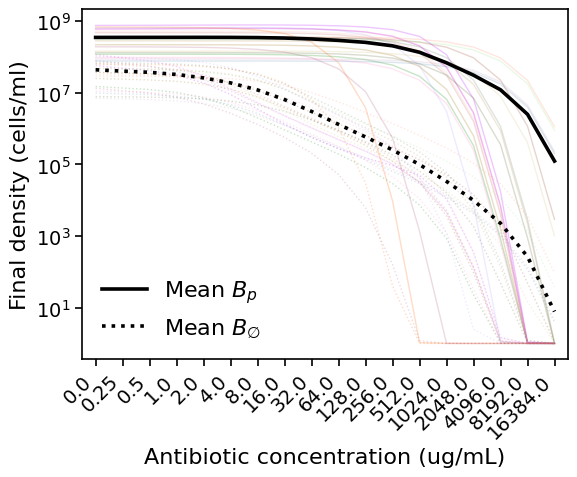

In [332]:
# Figure 2E-like dose-response experiment for all strains independently.
#
# Each simulation:
#   one strain
#   one transfer
#   initially plasmid-bearing
#   one fixed antibiotic concentration A0

config_E = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "initial_plasmid_fraction": 1.0,
    }
)

all_dose_rows = []
all_loaded_E_results = {}

strain_list = sorted(model_params["strain"].unique())

print("Number of strains:", len(strain_list))
print("Number of doses:", len(A_values))

for strain_id in strain_list:

    members = [strain_id]
    all_loaded_E_results[strain_id] = []

    print("Running/loading strain:", strain_id)

    for A0 in A_values:

        environment_E = pn.make_constant_environment(
            n_transfers=1,
            concentration=A0,
        )

        run_id = f"fig2E_{strain_id}_A{A0:g}_Bp_init"

        save_file_E = figure_run_path / f"{run_id}.pkl.gz"

        if save_file_E.exists():
            loaded_E = pn.load_simulation(save_file_E)

        else:
            result_E = pn.simulate_serial_transfers(
                model_params,
                members=members,
                environment=environment_E,
                config=config_E,
                run_id=run_id,
                metadata={
                    "figure": "Figure 2E",
                    "description": "Dose-response experiment; initially plasmid-bearing population",
                    "strain_id": strain_id,
                    "A0": A0,
                    "initial_plasmid_fraction": 1.0,
                },
            )

            pn.save_simulation(result_E, save_file_E)
            loaded_E = pn.load_simulation(save_file_E)

        all_loaded_E_results[strain_id].append(loaded_E)

        # Extract final densities
        tr = loaded_E.transfers[0]
        y = tr["y"]
        n = len(loaded_E.members)

        Bp_final = y[2 : 2 + n, -1].sum()
        Bempty_final = y[2 + n : 2 + 2 * n, -1].sum()
        Btotal_final = Bp_final + Bempty_final

        if Btotal_final > 0:
            plasmid_fraction = Bp_final / Btotal_final
        else:
            plasmid_fraction = np.nan

        all_dose_rows.append(
            {
                "run_id": run_id,
                "strain": strain_id,
                "A0": A0,
                "Bp_final": Bp_final,
                "Bempty_final": Bempty_final,
                "Btotal_final": Btotal_final,
                "plasmid_fraction": plasmid_fraction,
                "save_file": str(save_file_E),
            }
        )

dose_response_all_strains_df = pd.DataFrame(all_dose_rows)

dose_response_all_strains_df = dose_response_all_strains_df.sort_values(
    ["strain", "A0"]
).reset_index(drop=True)

summary_file = figure_run_path / "fig2E_all_strains_dose_response_final_densities.csv"
dose_response_all_strains_df.to_csv(summary_file, index=False)

display(dose_response_all_strains_df.head())

print("Saved all-strain dose-response summary to:", summary_file)

plot_df = dose_response_all_strains_df.copy()

# Use the correct strain column
if "strain" in plot_df.columns:
    strain_col = "strain"
elif "strain_id" in plot_df.columns:
    strain_col = "strain_id"
else:
    raise KeyError("Could not find either 'strain' or 'strain_id' in plot_df.")

plot_df["A0_log2"], _, _ = make_log2_dose_positions(plot_df["A0"])

summary_df = (
    plot_df
    .groupby("A0")
    .agg(
        Bp_mean=("Bp_final", "mean"),
        Bempty_mean=("Bempty_final", "mean"),
        Btotal_mean=("Btotal_final", "mean"),
    )
    .reset_index()
)

summary_df["A0_log2"], _, _ = make_log2_dose_positions(summary_df["A0"])

# Build strain color map
strain_color_map = make_strain_color_map(
    plot_df[strain_col].unique(),
    model_params=model_params,
    strain_col="strain",
    color_col="color",
)

fig, ax = plt.subplots(figsize=(6,5))

alpha_lines = 0.22
linewidth = 1.0
eps = 1.0

for strain_id, sub in plot_df.groupby(strain_col):

    sub = sub.sort_values("A0_log2")
    color = strain_color_map.get(str(strain_id), "gray")

    ax.plot(
        sub["A0_log2"],
        sub["Bp_final"] + eps,
        linestyle="-",
        linewidth=linewidth,
        alpha=alpha_lines,
        color=color,
    )

    ax.plot(
        sub["A0_log2"],
        sub["Bempty_final"] + eps,
        linestyle=":",
        linewidth=linewidth,
        alpha=alpha_lines,
        color=color,
    )

# Mean Bp
ax.plot(
    summary_df["A0_log2"],
    summary_df["Bp_mean"] + eps,
    linestyle="-",
    linewidth=2.6,
    color="black",
    label=r"Mean $B_p$",
)

# Mean Bempty
ax.plot(
    summary_df["A0_log2"],
    summary_df["Bempty_mean"] + eps,
    linestyle=":",
    linewidth=2.6,
    color="black",
    label=r"Mean $B_\emptyset$",
)

apply_log2_dose_axis(ax, plot_df["A0"])

ax.set_yscale("log")
ax.set_ylabel(f"Final density (cells/ml)")

ax.legend(frameon=False)

fig.tight_layout()

save_file = figure_save_path / "fig2E_all_strains_dose_response_with_mean_log2x.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [333]:
# Experiment 3 local helpers.
# Later we can move these into plasmidNoise_plotter.py.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

def extract_final_community_state(
    result,
    density_extinction_threshold=extinction_threshold,
):
    """
    Extract final Bp, Bempty, Btotal, and plasmid frequency
    from a loaded simulation result.

    Densities below density_extinction_threshold are treated as extinct.
    """
    tr = result.transfers[-1]
    y = tr["y"]
    n = len(result.members)

    Bp_final_by_strain = y[2 : 2 + n, -1].copy()
    Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

    Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
    Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

    Bp_final = Bp_final_by_strain.sum()
    Bempty_final = Bempty_final_by_strain.sum()
    Btotal_final = Bp_final + Bempty_final

    if Btotal_final > 0:
        plasmid_frequency = Bp_final / Btotal_final
    else:
        plasmid_frequency = np.nan

    return {
        "Bp_final": Bp_final,
        "Bempty_final": Bempty_final,
        "Btotal_final": Btotal_final,
        "plasmid_frequency": plasmid_frequency,
    }


def plot_multistrain_dose_response_log(df, save_path=None, eps=1.0):
    """
    Plot dose-response curve with log-scale y-axis.
    """
    fig, ax = plt.subplots(figsize=(5.4, 3.8))

    ax.plot(df["A0"], df["Bp_final"] + eps, marker="o", label=r"$B_p$")
    ax.plot(df["A0"], df["Bempty_final"] + eps, marker="o", label=r"$B_\emptyset$")
    ax.plot(df["A0"], df["Btotal_final"] + eps, marker="o", linestyle="--", label=r"$B_{total}$")

    ax.set_yscale("log")

    ax.set_xlabel("Antibiotic concentration (ug/mL)")
    ax.set_ylabel("Final density (cells/ml)")
    ax.legend(frameon=False)


    add_log2_dose_axis(ax, plot_df["A0"])

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


def plot_members_vs_plasmid_frequency(df, save_path=None):
    """
    Plot community size vs final plasmid frequency for random communities.
    """
    fig, ax = plt.subplots(figsize=(6.2, 4.0))

    rng = np.random.default_rng(123)

    for condition, sub in df.groupby("condition"):
        jitter = rng.normal(0, 0.06, size=len(sub))
        ax.scatter(
            sub["n_members"] + jitter,
            sub["plasmid_frequency"],
            alpha=0.55,
            label=condition,
        )

        summary = (
            sub.groupby("n_members")["plasmid_frequency"]
            .agg(["mean", "sem"])
            .reset_index()
        )

        ax.errorbar(
            summary["n_members"],
            summary["mean"],
            yerr=summary["sem"],
            marker="o",
            linewidth=2,
            capsize=3,
        )

    ax.set_xlabel("Number of community members")
    ax.set_ylabel("Final plasmid frequency")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title("Community size vs plasmid frequency")
    ax.legend(frameon=False)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


In [334]:
# Constant-environment serial-transfer dose-response for all strains.
#
# Each simulation:
#   one strain in isolation
#   Bp starts at 1e6
#   Bempty starts at 0
#   constant antibiotic concentration A0
#   serial transfers for num_days days

num_days_constant = num_days
B0_single_strain = 1e6
force_rerun = True

config_constant_serial = pn.SimulationConfig(
    **{
        **base_config.__dict__,
        "B0_total": B0_single_strain,
        "initial_plasmid_fraction": 1.0,
    }
)

constant_serial_run_path = figure_run_path / "single_strain_constant_serial_dose_response"
constant_serial_run_path.mkdir(parents=True, exist_ok=True)

constant_serial_fig_path = figure_save_path / "single_strain_constant_serial_dose_response"
constant_serial_fig_path.mkdir(parents=True, exist_ok=True)

strain_list = sorted(model_params["strain"].unique())

constant_serial_rows = []
constant_serial_loaded_results = {}

total_sims = len(strain_list) * len(A_values)
sim_counter = 0
run_counter = 0
load_counter = 0

print("Number of strains:", len(strain_list))
print("Number of doses:", len(A_values))
print("Number of simulations:", total_sims)
print("num_days_constant:", num_days_constant)
print("Run path:", constant_serial_run_path)

for strain_id in strain_list:

    members = [strain_id]

    for A0 in A_values:

        sim_counter += 1

        environment = pn.make_constant_environment(
            n_transfers=num_days_constant,
            concentration=A0,
        )

        run_id = (
            f"constantSerial_singleStrain_{strain_id}_"
            f"A{A0:g}_N{num_days_constant}_BpInit"
        )

        save_file = constant_serial_run_path / f"{run_id}.pkl.gz"

        print(
            f"[{sim_counter:04d}/{total_sims:04d}] "
            f"strain={strain_id} | A0={A0:g}"
        )

        if force_rerun and save_file.exists():
            save_file.unlink()
            print("    deleted old saved simulation; rerunning...")

        if save_file.exists():
            loaded = pn.load_simulation(save_file)
            load_counter += 1

        else:
            result = pn.simulate_serial_transfers(
                model_params,
                members=members,
                environment=environment,
                config=config_constant_serial,
                run_id=run_id,
                metadata={
                    "experiment": "Constant serial-transfer dose-response",
                    "description": "Single strain in constant antibiotic environment for multiple transfers",
                    "strain_id": strain_id,
                    "A0": A0,
                    "n_transfers": num_days_constant,
                    "initial_plasmid_fraction": 0.5,
                    "B0_total": B0_single_strain,
                    "members": members,
                },
            )

            pn.save_simulation(result, save_file)
            loaded = pn.load_simulation(save_file)
            run_counter += 1

        if len(loaded.transfers) != num_days_constant:
            print(
                f"    WARNING: loaded simulation has {len(loaded.transfers)} transfers, "
                f"expected {num_days_constant}"
            )

        constant_serial_loaded_results[(strain_id, A0)] = loaded

        final_state = extract_final_community_state(
            loaded,
            density_extinction_threshold=config_constant_serial.extinction_threshold,
        )

        constant_serial_rows.append(
            {
                "run_id": run_id,
                "strain_id": strain_id,
                "A0": A0,
                "n_transfers": num_days_constant,
                "Bp_final": final_state["Bp_final"],
                "Bempty_final": final_state["Bempty_final"],
                "Btotal_final": final_state["Btotal_final"],
                "plasmid_fraction": final_state["plasmid_frequency"],
                "save_file": str(save_file),
            }
        )

constant_serial_summary_df = pd.DataFrame(constant_serial_rows)

constant_serial_summary_df = constant_serial_summary_df.sort_values(
    ["A0", "strain_id"]
).reset_index(drop=True)

summary_file = (
    constant_serial_run_path
    / "single_strain_constant_serial_dose_response_summary.csv"
)

constant_serial_summary_df.to_csv(summary_file, index=False)

display(constant_serial_summary_df.head())

print("New simulations run:", run_counter)
print("Saved simulations loaded:", load_counter)
print("Saved summary table to:", summary_file)

Number of strains: 20
Number of doses: 18
Number of simulations: 360
num_days_constant: 32
Run path: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/figure2_initial_conditions/single_strain_constant_serial_dose_response
[0001/0360] strain=C002 | A0=0
    deleted old saved simulation; rerunning...
[0002/0360] strain=C002 | A0=0.25
    deleted old saved simulation; rerunning...
[0003/0360] strain=C002 | A0=0.5
    deleted old saved simulation; rerunning...
[0004/0360] strain=C002 | A0=1
    deleted old saved simulation; rerunning...
[0005/0360] strain=C002 | A0=2
    deleted old saved simulation; rerunning...
[0006/0360] strain=C002 | A0=4
    deleted old saved simulation; rerunning...
[0007/0360] strain=C002 | A0=8
    deleted old saved simulation; rerunning...
[0008/0360] strain=C002 | A0=16
    deleted old saved simulation; rerunning...
[0009/0360] strain=C002 | A0=32
    deleted old saved simulation; rerunning...
[0010/0360] strain=C002 | A0=64
    deleted old sav

,run_id,strain_id,A0,n_transfers,Bp_final,Bempty_final,Btotal_final,plasmid_fraction,save_file
0,constantSerial_singleStrain_C002_A0_N32_BpInit,C002,0.0,32,1.355839e+10,4.419220e+09,1.797761e+10,0.754182,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
1,constantSerial_singleStrain_C006_A0_N32_BpInit,C006,0.0,32,2.592074e+10,2.332505e+09,2.825325e+10,0.917443,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
2,constantSerial_singleStrain_C022_A0_N32_BpInit,C022,0.0,32,2.409607e+10,8.039425e+09,3.213549e+10,0.749827,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
3,constantSerial_singleStrain_C063_A0_N32_BpInit,C063,0.0,32,3.350943e+10,2.409287e+07,3.353352e+10,0.999282,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
4,constantSerial_singleStrain_C107_A0_N32_BpInit,C107,0.0,32,2.846562e+10,1.149686e+05,2.846574e+10,0.999996,/content/drive/MyDrive/SYNC_Projects/plasmidNo...


New simulations run: 360
Saved simulations loaded: 0
Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/figure2_initial_conditions/single_strain_constant_serial_dose_response/single_strain_constant_serial_dose_response_summary.csv


In [335]:
def extract_single_strain_daily_endpoint_densities(
    result,
    *,
    strain_id,
    A0,
    density_extinction_threshold=1e5,
):
    """
    Extract daily endpoint densities from a single-strain serial-transfer simulation.

    Returns one row per transfer/day.
    """

    rows = []

    for transfer_idx, tr in enumerate(result.transfers):

        y = tr["y"]

        # For a single-strain simulation:
        # y[0] = R
        # y[1] = A
        # y[2] = Bp
        # y[3] = Bempty
        Bp_final = float(y[2, -1])
        Bempty_final = float(y[3, -1])

        if Bp_final < density_extinction_threshold:
            Bp_final = 0.0

        if Bempty_final < density_extinction_threshold:
            Bempty_final = 0.0

        Btotal_final = Bp_final + Bempty_final

        if Btotal_final > 0:
            plasmid_fraction = Bp_final / Btotal_final
        else:
            plasmid_fraction = np.nan

        rows.append(
            {
                "run_id": result.run_id,
                "strain_id": strain_id,
                "A0": A0,
                "transfer": transfer_idx,
                "day": transfer_idx + 1,
                "Bp_final": Bp_final,
                "Bempty_final": Bempty_final,
                "Btotal_final": Btotal_final,
                "plasmid_fraction": plasmid_fraction,
            }
        )

    return pd.DataFrame(rows)

In [336]:
constant_serial_daily_dfs = []

for (strain_id, A0), loaded_result in constant_serial_loaded_results.items():

    daily_df = extract_single_strain_daily_endpoint_densities(
        loaded_result,
        strain_id=strain_id,
        A0=A0,
        density_extinction_threshold=config_constant_serial.extinction_threshold,
    )

    constant_serial_daily_dfs.append(daily_df)

constant_serial_daily_df = pd.concat(
    constant_serial_daily_dfs,
    ignore_index=True,
)

constant_serial_daily_df = constant_serial_daily_df.sort_values(
    ["A0", "strain_id", "day"]
).reset_index(drop=True)

daily_file = (
    constant_serial_run_path
    / "single_strain_constant_serial_dose_response_daily_densities.csv"
)

constant_serial_daily_df.to_csv(daily_file, index=False)

display(constant_serial_daily_df.head())

print("Saved daily endpoint densities to:", daily_file)

,run_id,strain_id,A0,transfer,day,Bp_final,Bempty_final,Btotal_final,plasmid_fraction
0,constantSerial_singleStrain_C002_A0_N32_BpInit,C002,0.0,0,1,1.202646e+08,1.511368e+07,1.353783e+08,0.888360
1,constantSerial_singleStrain_C002_A0_N32_BpInit,C002,0.0,1,2,5.930199e+08,1.084878e+08,7.015076e+08,0.845351
2,constantSerial_singleStrain_C002_A0_N32_BpInit,C002,0.0,2,3,1.053635e+09,2.169827e+08,1.270618e+09,0.829231
3,constantSerial_singleStrain_C002_A0_N32_BpInit,C002,0.0,3,4,1.507992e+09,3.332237e+08,1.841216e+09,0.819020
4,constantSerial_singleStrain_C002_A0_N32_BpInit,C002,0.0,4,5,1.958042e+09,4.547959e+08,2.412838e+09,0.811510


Saved daily endpoint densities to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/figure2_initial_conditions/single_strain_constant_serial_dose_response/single_strain_constant_serial_dose_response_daily_densities.csv


In [337]:
from matplotlib.lines import Line2D
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_constant_serial_dose_trajectories(
    daily_df,
    *,
    model_params,
    A_values_to_plot=None,
    save_path=None,
    density_eps=1.0,
    ncols=4,
    alpha=0.35,
    linewidth=1.1,
    mean_linewidth=2.8,
    plot_mean=True,
):
    """
    Plot daily endpoint trajectories for all single strains.

    One panel per antibiotic concentration.

    Colored lines:
        individual strains

    Black lines:
        mean trajectory across strains

    Solid line:
        plasmid-bearing cells, Bp

    Dashed line:
        plasmid-free cells, Bempty
    """

    plot_df = daily_df.copy()

    if A_values_to_plot is None:
        A_values_to_plot = sorted(plot_df["A0"].unique())

    A_values_to_plot = list(A_values_to_plot)

    strain_color_map = make_strain_color_map(
        plot_df["strain_id"].unique(),
        model_params=model_params,
        strain_col="strain",
        color_col="color",
    )

    n_panels = len(A_values_to_plot)
    ncols = min(ncols, n_panels)
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes_flat = axes.flatten()

    for ax, A0 in zip(axes_flat, A_values_to_plot):

        sub_A = plot_df[plot_df["A0"] == A0].copy()

        # Individual strain trajectories
        for strain_id, sub in sub_A.groupby("strain_id"):

            sub = sub.sort_values("day")
            color = strain_color_map.get(str(strain_id), "gray")

            ax.plot(
                sub["day"],
                sub["Bp_final"] + density_eps,
                color=color,
                linestyle="-",
                linewidth=linewidth,
                alpha=alpha,
                zorder=1,
            )

            ax.plot(
                sub["day"],
                sub["Bempty_final"] + density_eps,
                color=color,
                linestyle="--",
                linewidth=linewidth,
                alpha=alpha,
                zorder=1,
            )

        # Mean trajectories across strains
        if plot_mean and len(sub_A) > 0:

            mean_df = (
                sub_A
                .groupby("day")
                .agg(
                    Bp_mean=("Bp_final", "mean"),
                    Bempty_mean=("Bempty_final", "mean"),
                )
                .reset_index()
                .sort_values("day")
            )

            ax.plot(
                mean_df["day"],
                mean_df["Bp_mean"] + density_eps,
                color="black",
                linestyle="-",
                linewidth=mean_linewidth,
                zorder=10,
                label=r"Mean $B_p$",
            )

            ax.plot(
                mean_df["day"],
                mean_df["Bempty_mean"] + density_eps,
                color="black",
                linestyle="--",
                linewidth=mean_linewidth,
                zorder=10,
                label=r"Mean $B_\emptyset$",
            )

        ax.set_yscale("log")
        ax.set_title(f"A0 = {A0:g}")
        ax.set_xlabel("Time (day)")
        ax.set_ylabel("Daily density")

    for ax in axes_flat[n_panels:]:
        ax.axis("off")

    style_handles = [
        Line2D(
            [0], [0],
            color="black",
            linestyle="-",
            linewidth=mean_linewidth,
            label=r"Mean $B_p$",
        ),
        Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            linewidth=mean_linewidth,
            label=r"Mean $B_\emptyset$",
        ),
    ]

    fig.legend(
        handles=style_handles,
        frameon=False,
        loc="upper right",
        title="Subpopulation",
    )

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, axes

Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T32/figure2_initial_conditions/single_strain_constant_serial_dose_response/single_strain_constant_serial_dose_response_trajectories.png


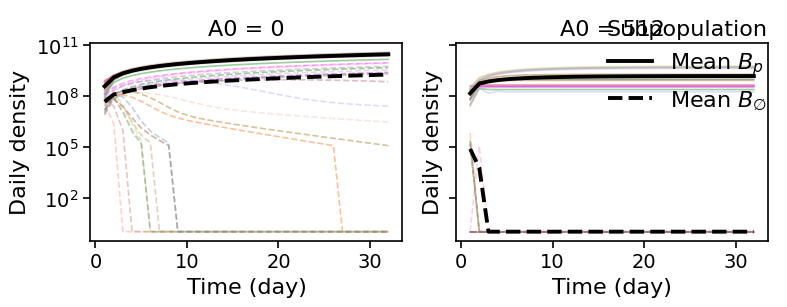

In [338]:
# Plot all doses. If there are many A_values, use a subset first.

A_values_to_plot = [0, 512] #A_values[0:8]
# Example subset:
# A_values_to_plot = [0, 1, 4, 16, 64, 256, 1024]

fig, axes = plot_constant_serial_dose_trajectories(
    constant_serial_daily_df,
    model_params=model_params,
    A_values_to_plot=A_values_to_plot,
    save_path=(
        constant_serial_fig_path
        / "single_strain_constant_serial_dose_response_trajectories.png"
    ),
    ncols=4,
    alpha=0.4,#
    linewidth=1.2,
)

plt.show()

## Constant antibiotic environments in multistrain communities

The second part of the notebook asks how community composition changes plasmid maintenance under constant selection. These simulations keep the antibiotic environment fixed and vary the set of host backgrounds available to the conjugative plasmid.


In [339]:
# Simulation settings for constant-environment community experiments.

experiment3_run_path = runPath / "experiment3_multistrain_constant"
experiment3_run_path.mkdir(parents=True, exist_ok=True)

experiment3_fig_path = figPath / "experiment3_multistrain_constant"
experiment3_fig_path.mkdir(parents=True, exist_ok=True)

available_members = sorted(model_params["strain"].unique())

print("Number of available strains:", len(available_members))
print("First strains:", available_members[:10])

# For whole-community simulations, use all available strains.
whole_community_members = available_members

# For random-community simulations, you can restrict this if needed.
random_pool = available_members


experiment3_config = pn.SimulationConfig(
    season_duration=24.0,
    points_per_season=121,
    R0=1.0,
    B0_total=B_initial,
    dilution=0.01,
    extinction_threshold=extinction_threshold,
    solver_method="LSODA",
    uptake_mode="monod",
    initial_plasmid_fraction=1.0,
)

print("Whole community size:", len(whole_community_members))


Number of available strains: 20
First strains: ['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324']
Whole community size: 20


### Complete-community dose-response

The complete parameterized community is exposed to a constant-dose series. The endpoint total density, plasmid fraction, and final strain frequencies quantify how antibiotic selection reshapes both plasmid state and community composition.


In [340]:
# Experiment 3.1
# Whole-community dose-response curve in constant environments.
#
# Run -> save -> load -> summarize


whole_community_loaded_results = []
whole_community_rows = []

for A0 in A_values:
    environment = pn.make_constant_environment(
        n_transfers=num_days,
        concentration=A0,
    )

    run_id = f"exp3_wholeCommunity_N{num_days}_A{A0:g}"

    result = pn.simulate_serial_transfers(
        model_params,
        members=whole_community_members,
        environment=environment,
        config=experiment3_config,
        run_id=run_id,
        metadata={
            "experiment": "Experiment 3.1",
            "description": "Whole-community dose response in constant environments",
            "A0": A0,
            "n_members": len(whole_community_members),
            "members": whole_community_members,
        },
    )

    save_file = pn.save_simulation(
        result,
        experiment3_run_path / f"{run_id}.pkl.gz",
    )

    loaded = pn.load_simulation(save_file)
    whole_community_loaded_results.append(loaded)

    final_state = extract_final_community_state(loaded)

    whole_community_rows.append(
        {
            "run_id": run_id,
            "A0": A0,
            "n_members": len(whole_community_members),
            **final_state,
        }
    )

whole_community_dose_df = pd.DataFrame(whole_community_rows)
whole_community_dose_df = whole_community_dose_df.sort_values("A0").reset_index(drop=True)

summary_file = experiment3_run_path / "whole_community_dose_response_summary.csv"
whole_community_dose_df.to_csv(summary_file, index=False)

display(whole_community_dose_df)
print("Saved summary table to:", summary_file)


,run_id,A0,n_members,Bp_final,Bempty_final,Btotal_final,plasmid_frequency
0,exp3_wholeCommunity_N32_A0,0.00,20,8.075214e+08,8.417572e+07,8.916971e+08,0.905601
1,exp3_wholeCommunity_N32_A0.25,0.25,20,8.257044e+08,5.658525e+07,8.822897e+08,0.935865
2,exp3_wholeCommunity_N32_A0.5,0.50,20,8.360026e+08,4.075311e+07,8.767557e+08,0.953518
3,exp3_wholeCommunity_N32_A1,1.00,20,8.471735e+08,2.360979e+07,8.707833e+08,0.972887
4,exp3_wholeCommunity_N32_A2,2.00,20,8.577155e+08,9.540650e+06,8.672562e+08,0.988999
5,exp3_wholeCommunity_N32_A4,4.00,20,8.626850e+08,2.356165e+06,8.650412e+08,0.997276
6,exp3_wholeCommunity_N32_A8,8.00,20,8.634548e+08,3.097896e+05,8.637646e+08,0.999641
7,exp3_wholeCommunity_N32_A16,16.00,20,8.569546e+08,0.000000e+00,8.569546e+08,1.000000
8,exp3_wholeCommunity_N32_A32,32.00,20,8.396339e+08,0.000000e+00,8.396339e+08,1.000000
9,exp3_wholeCommunity_N32_A64,64.00,20,8.049571e+08,0.000000e+00,8.049571e+08,1.000000


Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/experiment3_multistrain_constant/whole_community_dose_response_summary.csv


In [341]:
# Extract final strain frequencies from the whole-community dose-response simulations.
#
# This uses:
# whole_community_loaded_results
#
# Each row = one strain in one dose.

whole_community_strain_rows = []

for result in whole_community_loaded_results:
    tr = result.transfers[-1]
    y = tr["y"]
    n = len(result.members)

    A0 = tr["A_initial"]
    print(A0)

    Bp_final_by_strain = y[2 : 2 + n, -1]
    Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1]
    Btotal_final_by_strain = Bp_final_by_strain + Bempty_final_by_strain

    community_total_final = Btotal_final_by_strain.sum()

    for strain, Bp_i, Bempty_i, Btotal_i in zip(
        result.members,
        Bp_final_by_strain,
        Bempty_final_by_strain,
        Btotal_final_by_strain,
    ):
        strain_frequency = np.nan
        strain_plasmid_frequency = np.nan

        if community_total_final > 0:
            strain_frequency = Btotal_i / community_total_final

        if Btotal_i > 0:
            strain_plasmid_frequency = Bp_i / Btotal_i

        whole_community_strain_rows.append(
            {
                "run_id": result.run_id,
                "A0": A0,
                "strain": strain,
                "Bp_final": Bp_i,
                "Bempty_final": Bempty_i,
                "Btotal_final": Btotal_i,
                "strain_frequency": strain_frequency,
                "strain_plasmid_frequency": strain_plasmid_frequency,
                "community_total_final": community_total_final,
            }
        )

whole_community_strain_df = pd.DataFrame(whole_community_strain_rows)
whole_community_strain_df = whole_community_strain_df.sort_values(
    ["A0", "strain"]
).reset_index(drop=True)

summary_file = experiment3_run_path / "whole_community_strain_frequency_summary.csv"
whole_community_strain_df.to_csv(summary_file, index=False)

display(whole_community_strain_df[0:20])
print("Saved strain-level summary table to:", summary_file)


0.0
0.25
0.5
1.0
2.0
4.0
8.0
16.0
32.0
64.0
128.0
256.0
512.0
1024.0
2048.0
4096.0
8192.0
16384.0


,run_id,A0,strain,Bp_final,Bempty_final,Btotal_final,strain_frequency,strain_plasmid_frequency,community_total_final
0,exp3_wholeCommunity_N32_A0,0.0,C002,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
1,exp3_wholeCommunity_N32_A0,0.0,C006,8.075214e+08,8.417572e+07,8.916971e+08,1.0,0.905601,8.916971e+08
2,exp3_wholeCommunity_N32_A0,0.0,C022,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
3,exp3_wholeCommunity_N32_A0,0.0,C063,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
4,exp3_wholeCommunity_N32_A0,0.0,C107,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
5,exp3_wholeCommunity_N32_A0,0.0,C201,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
6,exp3_wholeCommunity_N32_A0,0.0,C247,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
7,exp3_wholeCommunity_N32_A0,0.0,C286,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
8,exp3_wholeCommunity_N32_A0,0.0,C290,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08
9,exp3_wholeCommunity_N32_A0,0.0,C324,0.000000e+00,0.000000e+00,0.000000e+00,0.0,NaN,8.916971e+08


Saved strain-level summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/experiment3_multistrain_constant/whole_community_strain_frequency_summary.csv


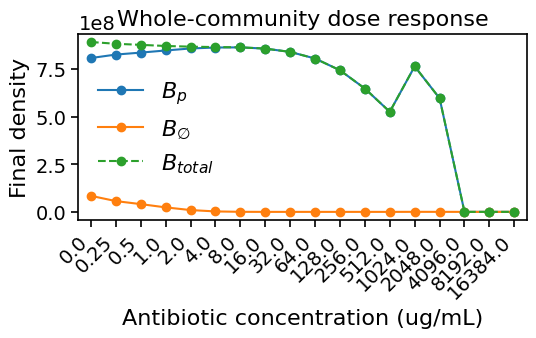

In [342]:
def plot_multistrain_dose_response(df, save_path=None):
    """
    Plot dose-response curve for whole-community simulations.

    The x-axis uses log2 spacing for A0 > 0, while keeping A0 = 0
    as a separate no-drug control point.
    """

    plot_df = df.copy()
    plot_df = plot_df.sort_values("A0").reset_index(drop=True)

    plot_df["A0_log2"], _, _ = make_log2_dose_positions(plot_df["A0"])

    fig, ax = plt.subplots(figsize=(5.4, 3.8))

    ax.plot(
        plot_df["A0_log2"],
        plot_df["Bp_final"],
        marker="o",
        label=r"$B_p$",
    )

    ax.plot(
        plot_df["A0_log2"],
        plot_df["Bempty_final"],
        marker="o",
        label=r"$B_\emptyset$",
    )

    ax.plot(
        plot_df["A0_log2"],
        plot_df["Btotal_final"],
        marker="o",
        linestyle="--",
        label=r"$B_{total}$",
    )

    apply_log2_dose_axis(ax, plot_df["A0"])

    ax.set_ylabel("Final density")
    ax.set_title("Whole-community dose response")
    ax.legend(frameon=False)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


# Plot whole-community dose response

fig, ax = plot_multistrain_dose_response(
    whole_community_dose_df,
    save_path=experiment3_fig_path / "whole_community_dose_response.png",
)


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T32/experiment3_multistrain_constant/whole_community_strain_frequencies_top8_legend_log2x.png
Top strains in legend: ['C006', 'K213', 'C022', 'C002', 'C063', 'C107', 'C247', 'C201']


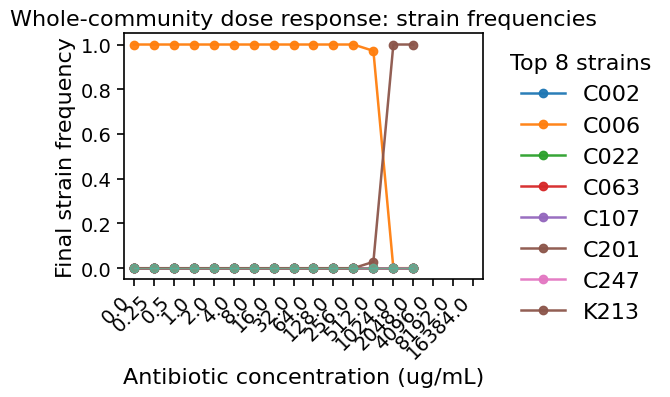

In [343]:
# Plot final frequency of each strain across antibiotic doses,

top_n_strains = 8

plot_df = whole_community_strain_df.copy()
plot_df = plot_df.sort_values(["A0", "strain"]).reset_index(drop=True)

plot_df["A0_log2"], _, _ = make_log2_dose_positions(plot_df["A0"])

top_strains = (
    plot_df
    .groupby("strain")["strain_frequency"]
    .max()
    .sort_values(ascending=False)
    .head(top_n_strains)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(6.5, 4.2))

for strain, sub in plot_df.groupby("strain"):
    sub = sub.sort_values("A0_log2")

    if strain in top_strains:
        ax.plot(
            sub["A0_log2"],
            sub["strain_frequency"],
            marker="o",
            linewidth=1.8,
            alpha=0.95,
            label=strain,
        )
    else:
        ax.plot(
            sub["A0_log2"],
            sub["strain_frequency"],
            marker="o",
            linewidth=1.0,
            alpha=0.35,
            label="_nolegend_",
        )

apply_log2_dose_axis(ax, plot_df["A0"])

ax.set_ylabel("Final strain frequency")
ax.set_title("Whole-community dose response: strain frequencies")

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title=f"Top {top_n_strains} strains",
)

fig.tight_layout()

save_file = experiment3_fig_path / "whole_community_strain_frequencies_top8_legend_log2x.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)
print("Top strains in legend:", top_strains)


### Random communities under constant antibiotic exposure

Randomly sampled communities are used to measure how community composition changes the outcome of the same antibiotic concentration. This analysis separates drug intensity from host-community effects.


In [344]:


rng = np.random.default_rng(123)

# Community sizes to sample.
# With 25 strains, we can sample from monocultures up to full 25-member communities.
max_random_community_size = min(25, len(random_pool))
M_values = list(range(1, max_random_community_size + 1))

# Number of random communities per size per condition.
# This gives balanced sampling across community sizes.


constant_conditions = [
    {
        "condition": "no_drug",
        "A0": Amin,
    },
    {
        "condition": "drug",
        "A0": Amax,
    },
]

full_sampled_design_size = (
    len(constant_conditions)
    * len(M_values)
    * num_communities_per_size
)

actual_design_size = (
    min(max_total_simulations, full_sampled_design_size)
    if max_total_simulations is not None
    else full_sampled_design_size
)

print("Random pool size:", len(random_pool))
print("Community sizes:", M_values)
print("Replicates per size per condition:", num_communities_per_size)
print("Conditions:", constant_conditions)
print("Full sampled design size:", full_sampled_design_size)
print("Max total simulations:", max_total_simulations)
print("Simulations to run:", actual_design_size)


Random pool size: 20
Community sizes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Replicates per size per condition: 100
Conditions: [{'condition': 'no_drug', 'A0': 0.0}, {'condition': 'drug', 'A0': 512.0}]
Full sampled design size: 4000
Max total simulations: 1000
Simulations to run: 1000


In [345]:
# Random-community simulations.
#
# Resume-able batch version:
# - If a simulation file already exists, load it.
# - If not, run -> save -> load.
# - Always summarize all available runs.
#
# This lets us simulate in batches and later re-run this cell
# without repeating completed simulations.

random_community_run_path = experiment3_run_path / "random_communities"
random_community_run_path.mkdir(parents=True, exist_ok=True)

random_community_rows = []

sim_counter = 0
run_counter = 0
skip_counter = 0
stop_running = False

for condition_info in constant_conditions:
    if stop_running:
        break

    condition = condition_info["condition"]
    A0 = condition_info["A0"]

    for M in M_values:
        if stop_running:
            break

        for rep in range(num_communities_per_size):

            if max_total_simulations is not None and sim_counter >= max_total_simulations:
                stop_running = True
                break

            # Important:
            # Because we use a fixed rng seed at the start of the design cell,
            # this will regenerate the same communities every time the notebook is rerun,
            # as long as the loop order and design are unchanged.
            members = sorted(
                rng.choice(random_pool, size=M, replace=False).tolist()
            )

            run_id = (
                f"exp3_randomCommunity_"
                f"{condition}_A{A0:g}_M{M}_rep{rep:03d}"
            )

            save_file = random_community_run_path / f"{run_id}.pkl.gz"

            print(
                f"[{sim_counter + 1:03d}/{actual_design_size:03d}] "
                f"{condition} | A={A0:g} | M={M:02d} | rep={rep:03d} | "
                f"members={','.join(members)}"
            )

            if save_file.exists():
                #print("    found saved simulation, loading...")
                loaded = pn.load_simulation(save_file)
                skip_counter += 1

            else:
                #print("    saved simulation not found, running...")

                environment = pn.make_constant_environment(
                    n_transfers=num_days,
                    concentration=A0,
                )

                result = pn.simulate_serial_transfers(
                    model_params,
                    members=members,
                    environment=environment,
                    config=experiment3_config,
                    run_id=run_id,
                    metadata={
                        "experiment": "Experiment 3.2",
                        "description": "Random communities in constant environments",
                        "condition": condition,
                        "A0": A0,
                        "n_members": M,
                        "rep": rep,
                        "members": members,
                    },
                )

                pn.save_simulation(result, save_file)
                loaded = pn.load_simulation(save_file)
                run_counter += 1

            final_state = extract_final_community_state(
                loaded,
                density_extinction_threshold=experiment3_config.extinction_threshold,
            )

            Bp_final = final_state["Bp_final"]
            Bempty_final = final_state["Bempty_final"]
            Btotal_final = final_state["Btotal_final"]
            plasmid_frequency = final_state["plasmid_frequency"]

            random_community_rows.append(
                {
                    "run_id": run_id,
                    "condition": condition,
                    "A0": A0,
                    "n_members": M,
                    "rep": rep,
                    "members": ";".join(members),
                    "save_file": str(save_file),
                    "Bp_final": Bp_final,
                    "Bempty_final": Bempty_final,
                    "Btotal_final": Btotal_final,
                    "plasmid_frequency": plasmid_frequency,
                }
            )

            print(
                f"    result | "
                f"Btotal={Btotal_final:.3e} | "
                f"Bp={Bp_final:.3e} | "
                f"Bempty={Bempty_final:.3e} | "
                f"plasmid_freq={plasmid_frequency:.3f}"
            )

            sim_counter += 1

random_community_df = pd.DataFrame(random_community_rows)

if len(random_community_df) > 0:
    random_community_df = random_community_df.sort_values(
        ["condition", "n_members", "rep"]
    ).reset_index(drop=True)

    summary_file = experiment3_run_path / "random_communities_summary.csv"
    random_community_df.to_csv(summary_file, index=False)

    display(random_community_df.head())

    print("Number of simulations in summary:", len(random_community_df))
    print("New simulations run:", run_counter)
    print("Saved simulations loaded:", skip_counter)
    print("Saved summary table to:", summary_file)
else:
    print("No simulations were run or loaded.")


[001/1000] no_drug | A=0 | M=01 | rep=000 | members=C002
    result | Btotal=5.566e+08 | Bp=0.000e+00 | Bempty=5.566e+08 | plasmid_freq=0.000
[002/1000] no_drug | A=0 | M=01 | rep=001 | members=K177
    result | Btotal=7.763e+08 | Bp=0.000e+00 | Bempty=7.763e+08 | plasmid_freq=0.000
[003/1000] no_drug | A=0 | M=01 | rep=002 | members=K038
    result | Btotal=7.717e+08 | Bp=6.102e+08 | Bempty=1.615e+08 | plasmid_freq=0.791
[004/1000] no_drug | A=0 | M=01 | rep=003 | members=C006
    result | Btotal=8.918e+08 | Bp=8.076e+08 | Bempty=8.419e+07 | plasmid_freq=0.906
[005/1000] no_drug | A=0 | M=01 | rep=004 | members=K248
    result | Btotal=0.000e+00 | Bp=0.000e+00 | Bempty=0.000e+00 | plasmid_freq=nan
[006/1000] no_drug | A=0 | M=01 | rep=005 | members=C107
    result | Btotal=8.586e+08 | Bp=1.517e+08 | Bempty=7.069e+08 | plasmid_freq=0.177
[007/1000] no_drug | A=0 | M=01 | rep=006 | members=C201
    result | Btotal=1.098e+09 | Bp=9.362e+08 | Bempty=1.620e+08 | plasmid_freq=0.852
[008/100

,run_id,condition,A0,n_members,rep,members,save_file,Bp_final,Bempty_final,Btotal_final,plasmid_frequency
0,exp3_randomCommunity_no_drug_A0_M1_rep000,no_drug,0.0,1,0,C002,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.000000e+00,5.565964e+08,5.565964e+08,0.000000
1,exp3_randomCommunity_no_drug_A0_M1_rep001,no_drug,0.0,1,1,K177,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.000000e+00,7.762528e+08,7.762528e+08,0.000000
2,exp3_randomCommunity_no_drug_A0_M1_rep002,no_drug,0.0,1,2,K038,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,6.102183e+08,1.614702e+08,7.716884e+08,0.790757
3,exp3_randomCommunity_no_drug_A0_M1_rep003,no_drug,0.0,1,3,C006,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,8.076159e+08,8.418557e+07,8.918014e+08,0.905601
4,exp3_randomCommunity_no_drug_A0_M1_rep004,no_drug,0.0,1,4,K248,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.000000e+00,0.000000e+00,0.000000e+00,NaN


Number of simulations in summary: 1000
New simulations run: 0
Saved simulations loaded: 1000
Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/experiment3_multistrain_constant/random_communities_summary.csv


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T32/experiment3_multistrain_constant/random_communities_size_vs_plasmid_frequency.png


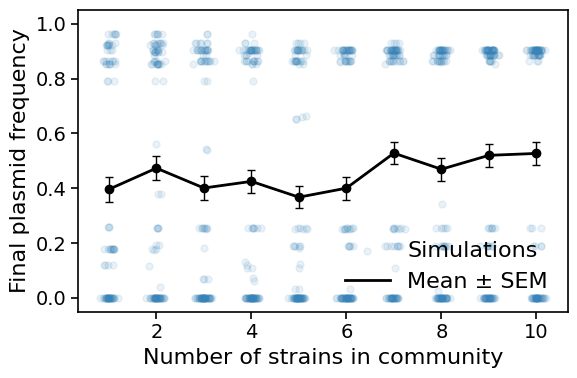

In [346]:
# Plot number of strains vs final plasmid frequency.

fig, ax = plt.subplots(figsize=(6., 4.))

rng_plot = np.random.default_rng(123)

for condition, sub in random_community_df.groupby("condition"):
    sub = sub.copy()

    jitter = rng_plot.normal(0, 0.08, size=len(sub))

    ax.scatter(
        sub["n_members"] + jitter,
        sub["plasmid_frequency"],
        color='#3784BA',
        alpha=0.1,
        s=25,
        label=f"Simulations",
    )

    summary = (
        sub.groupby("n_members")["plasmid_frequency"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    ax.plot(
        summary["n_members"],
        summary["mean"],
        linewidth=2,
        color='k',
        label=f"Mean ± SEM",
    )

    ax.errorbar(
        summary["n_members"],
        summary["mean"],
        yerr=summary["sem"],
        marker="o",
        color='k',
        linewidth=1,
        capsize=3,
    )

ax.set_xlabel("Number of strains in community", fontsize=16)
ax.set_ylabel("Final plasmid frequency", fontsize=16)
ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()

save_file = experiment3_fig_path / "random_communities_size_vs_plasmid_frequency.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T32/experiment3_multistrain_constant/random_communities_size_vs_total_density.png


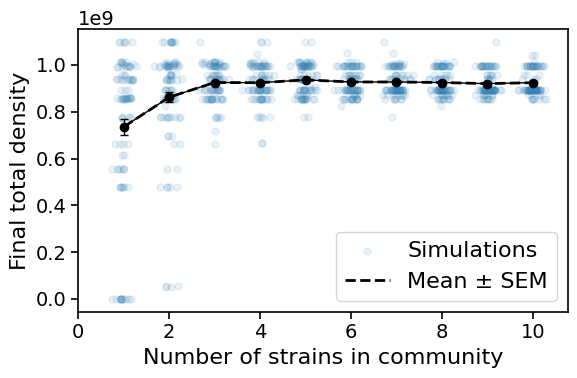

In [347]:
# Plot number of strains vs final total density.

fig, ax = plt.subplots(figsize=(6,4))

rng_plot = np.random.default_rng(123)

for condition, sub in random_community_df.groupby("condition"):
    sub = sub.copy()

    jitter = rng_plot.normal(0, 0.12, size=len(sub))

    ax.scatter(
        sub["n_members"] + jitter,
        sub["Btotal_final"],
        alpha=0.1,
        color='#3784BA',
        s=25,
        label=f"Simulations",
    )

    summary = (
        sub.groupby("n_members")["Btotal_final"]
        .agg(["mean", "sem"])
        .reset_index()
    )
    ax.plot(
        summary["n_members"],
        summary["mean"],
        linewidth=2,
        color='k',
        linestyle='--',
        label=f"Mean ± SEM",
    )


    ax.errorbar(
        summary["n_members"],
        summary["mean"],
        yerr=summary["sem"],
        linewidth=1,
        marker='o',
        capsize=3,
        color='k',
    )

ax.set_xlabel("Number of strains in community", fontsize=16)
ax.set_ylabel("Final total density", fontsize=16)
ax.set_xticks([0, 2, 4, 6, 8, 10])
#ax.set_yscale("log")
ax.legend(frameon=True, loc="lower right")

fig.tight_layout()

save_file = experiment3_fig_path / "random_communities_size_vs_total_density.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [348]:
# Experiment 3.2
# Randomly sampled multistrain communities.

exp32_run_path = runPath / "experiment3_2_random_communities"
exp32_run_path.mkdir(parents=True, exist_ok=True)

exp32_fig_path = figPath / "experiment3_2_random_communities"
exp32_fig_path.mkdir(parents=True, exist_ok=True)

available_members = sorted(model_params["strain"].unique())
random_pool = available_members

print("Number of available strains:", len(random_pool))
print("First strains:", random_pool[:10])


Number of available strains: 20
First strains: ['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324']


In [349]:
def summarize_metric(df, x_col, y_col):
    return (
        df.groupby(x_col)[y_col]
        .agg(["mean", "sem"])
        .reset_index()
    )
def plot_metric_vs_antibiotic(
    df,
    y_col,
    ylabel,
    title,
    save_path=None,
    log_y=False,
):
    """
    Plot a metric against antibiotic concentration.

    The x-axis uses log2 spacing for A0 > 0, while keeping A0 = 0
    as a separate no-drug control point.
    """

    plot_df = df.copy()
    plot_df = plot_df.sort_values("A0").reset_index(drop=True)

    plot_df["A0_log2"], _, _ = make_log2_dose_positions(plot_df["A0"])

    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    ax.scatter(
        plot_df["A0_log2"],
        plot_df[y_col],
        alpha=0.45,
        s=20,
        c="black",
    )

    summary = summarize_metric(plot_df, "A0", y_col)
    summary = summary.sort_values("A0").reset_index(drop=True)
    summary["A0_log2"], _, _ = make_log2_dose_positions(summary["A0"])

    ax.plot(
        summary["A0_log2"],
        summary["mean"],
        linewidth=2.5,
        color="black",
    )

    apply_log2_dose_axis(ax, plot_df["A0"])

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if log_y:
        ax.set_yscale("log")

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

def plot_metric_vs_community_size(df, y_col, ylabel, title, save_path=None, log_y=False):
    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    rng_plot = np.random.default_rng(123)
    jitter = rng_plot.normal(0, 0.08, size=len(df))

    ax.scatter(
        df["n_members"] + jitter,
        df[y_col],
        alpha=0.45,
        s=20,
        c="black",
    )

    summary = summarize_metric(df, "n_members", y_col)

    ax.plot(
        summary["n_members"],
        summary["mean"],
        linewidth=2.5,
    )

    ax.set_xlabel("Community size (M)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if log_y:
        ax.set_yscale("log")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


### Fixed-size communities across antibiotic concentrations

Random communities of fixed size are simulated across the dose range. This experiment asks whether communities with the same richness but different strain composition differ in plasmid fraction and final density.


In [350]:
# Experiment 3.2A-B
# Incremental random sampling without a design CSV.
#
# We use the directory contents as the record of what has already been simulated.
# Existing simulations are loaded from .pkl.gz files.
# Community members are recovered from simulation metadata.
# New communities are sampled only if we need more than already exist.

import re
import pandas as pd
import numpy as np
from pathlib import Path

exp32_run_path = runPath / "experiment3_2_random_communities"
exp32_run_path.mkdir(parents=True, exist_ok=True)

exp32_fig_path = figPath / "experiment3_2_random_communities"
exp32_fig_path.mkdir(parents=True, exist_ok=True)

exp32_AB_run_path = exp32_run_path / "AB_fixedM_varyA"
exp32_AB_run_path.mkdir(parents=True, exist_ok=True)

exp32_AB_fig_path = exp32_fig_path / "AB_fixedM_varyA"
exp32_AB_fig_path.mkdir(parents=True, exist_ok=True)

available_members = sorted(model_params["strain"].unique())
random_pool = available_members

rng = np.random.default_rng(123)


print("Number of available strains:", len(random_pool))
print("M_fixed:", M_fixed)
print("Target number of communities:", num_communities_M10)
print("A_values:", A_values)
print("Run path:", exp32_AB_run_path)


Number of available strains: 20
M_fixed: 5
Target number of communities: 1000
A_values: [0, 0.25, 0.5, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
Run path: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/experiment3_2_random_communities/AB_fixedM_varyA


In [351]:
# Scan existing simulation files and reconstruct existing communities.

existing_files = sorted(exp32_AB_run_path.glob("exp32_AB_M10_comm*_A*.pkl.gz"))

existing_community_members = {}
existing_community_set = set()

pattern = re.compile(r"exp32_AB_M10_comm(?P<community_index>\d+)_A(?P<A0>.+)\.pkl\.gz")

for file in existing_files:
    match = pattern.match(file.name)

    if match is None:
        continue

    loaded = pn.load_simulation(file)

    community_index = int(match.group("community_index"))

    # Prefer metadata because it stores the actual sampled community.
    members = loaded.metadata.get("members", None)

    if members is None:
        # Fallback, in case metadata is missing.
        members = loaded.members

    members = tuple(sorted(members))

    existing_community_members[community_index] = members
    existing_community_set.add(members)

print("Existing simulation files:", len(existing_files))
print("Existing unique communities:", len(existing_community_members))

if len(existing_community_members) > 0:
    print("First existing communities:")
    for community_index in sorted(existing_community_members)[:5]:
        print(f"  comm{community_index:03d}: {list(existing_community_members[community_index])}")


Existing simulation files: 18000
Existing unique communities: 1000
First existing communities:
  comm000: ['C002', 'C006', 'K037', 'K038', 'K248']
  comm001: ['C022', 'C201', 'C290', 'K209', 'K248']
  comm002: ['C002', 'C201', 'C324', 'K177', 'K213']
  comm003: ['C022', 'C063', 'C247', 'K112', 'K177']
  comm004: ['C063', 'C324', 'K177', 'K213', 'K216']


In [352]:
# Add new random communities only if the target has not been reached.

next_community_index = (
    max(existing_community_members.keys()) + 1
    if len(existing_community_members) > 0
    else 0
)

new_communities_added = 0

while len(existing_community_members) < num_communities_M10:
    members = tuple(sorted(rng.choice(random_pool, size=M_fixed, replace=False).tolist()))

    if members in existing_community_set:
        continue

    existing_community_members[next_community_index] = members
    existing_community_set.add(members)

    print(f"Added comm{next_community_index:03d}: {list(members)}")

    next_community_index += 1
    new_communities_added += 1

print("New communities added:", new_communities_added)
print("Total communities to evaluate:", len(existing_community_members))


New communities added: 0
Total communities to evaluate: 1000


In [353]:
# Run missing simulations, load existing ones, and rebuild summary.
#
# No design CSV is needed.
# The directory contents define what has already been simulated.

exp32_AB_rows = []

community_indices = sorted(existing_community_members.keys())

total_sims = len(community_indices) * len(A_values)

sim_counter = 0
run_counter = 0
skip_counter = 0

for community_index in community_indices:
    members = list(existing_community_members[community_index])

    for A0 in A_values:
        sim_counter += 1

        run_id = f"exp32_AB_M10_comm{community_index:03d}_A{A0:g}"
        save_file = exp32_AB_run_path / f"{run_id}.pkl.gz"

        print(
            f"[{sim_counter:03d}/{total_sims:03d}] "
            f"A={A0:g} | community={community_index:03d} | members={members}"
        )

        if save_file.exists():
            #print("    found saved simulation, loading...")
            loaded = pn.load_simulation(save_file)
            skip_counter += 1

        else:
            #print("    saved simulation not found, running...")

            environment = pn.make_constant_environment(
                n_transfers=num_days,
                concentration=A0,
            )

            result = pn.simulate_serial_transfers(
                model_params,
                members=members,
                environment=environment,
                config=experiment3_config,
                run_id=run_id,
                metadata={
                    "experiment": "3.2A-B",
                    "community_index": community_index,
                    "A0": A0,
                    "n_members": M_fixed,
                    "members": members,
                },
            )

            pn.save_simulation(result, save_file)
            loaded = pn.load_simulation(save_file)
            run_counter += 1

        final_state = extract_final_community_state(
            loaded,
            density_extinction_threshold=experiment3_config.extinction_threshold,
        )

        exp32_AB_rows.append(
            {
                "run_id": run_id,
                "community_index": community_index,
                "A0": A0,
                "n_members": M_fixed,
                "members": ";".join(members),
                "save_file": str(save_file),
                "plasmid_fraction": final_state["plasmid_frequency"],
                "bacterial_density": final_state["Btotal_final"],
                "Bp_final": final_state["Bp_final"],
                "Bempty_final": final_state["Bempty_final"],
            }
        )

        print(
            f"    result | "
            f"plasmid_fraction={final_state['plasmid_frequency']:.3f} | "
            f"bacterial_density={final_state['Btotal_final']:.3e} | "
            f"Bp={final_state['Bp_final']:.3e} | "
            f"Bempty={final_state['Bempty_final']:.3e}"
        )

exp32_AB_df = pd.DataFrame(exp32_AB_rows)
exp32_AB_df = exp32_AB_df.sort_values(
    ["A0", "community_index"]
).reset_index(drop=True)

summary_file = exp32_AB_run_path / "exp32_AB_summary.csv"
exp32_AB_df.to_csv(summary_file, index=False)

display(exp32_AB_df.head())

print("Summary rows:", len(exp32_AB_df))
print("New simulations run:", run_counter)
print("Saved simulations loaded:", skip_counter)
print("Saved summary table to:", summary_file)


Streaming output truncated to the last 5000 lines.
[15501/18000] A=0.5 | community=861 | members=['C286', 'K038', 'K213', 'K225', 'K248']
    result | plasmid_fraction=0.453 | bacterial_density=9.802e+08 | Bp=4.444e+08 | Bempty=5.358e+08
[15502/18000] A=1 | community=861 | members=['C286', 'K038', 'K213', 'K225', 'K248']
    result | plasmid_fraction=0.907 | bacterial_density=9.903e+08 | Bp=8.979e+08 | Bempty=9.242e+07
[15503/18000] A=2 | community=861 | members=['C286', 'K038', 'K213', 'K225', 'K248']
    result | plasmid_fraction=0.959 | bacterial_density=9.926e+08 | Bp=9.523e+08 | Bempty=4.034e+07
[15504/18000] A=4 | community=861 | members=['C286', 'K038', 'K213', 'K225', 'K248']
    result | plasmid_fraction=0.974 | bacterial_density=9.861e+08 | Bp=9.600e+08 | Bempty=2.611e+07
[15505/18000] A=8 | community=861 | members=['C286', 'K038', 'K213', 'K225', 'K248']
    result | plasmid_fraction=0.987 | bacterial_density=9.782e+08 | Bp=9.651e+08 | Bempty=1.311e+07
[15506/18000] A=16 | c

,run_id,community_index,A0,n_members,members,save_file,plasmid_fraction,bacterial_density,Bp_final,Bempty_final
0,exp32_AB_M10_comm000_A0,0,0.0,5,C002;C006;K037;K038;K248,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.905601,8.918014e+08,8.076159e+08,8.418557e+07
1,exp32_AB_M10_comm001_A0,1,0.0,5,C022;C201;C290;K209;K248,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.000000,9.971922e+08,0.000000e+00,9.971922e+08
2,exp32_AB_M10_comm002_A0,2,0.0,5,C002;C201;C324;K177;K213,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.864653,9.392283e+08,8.121062e+08,1.271222e+08
3,exp32_AB_M10_comm003_A0,3,0.0,5,C022;C063;C247;K112;K177,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.000000,8.533796e+08,0.000000e+00,8.533796e+08
4,exp32_AB_M10_comm004_A0,4,0.0,5,C063;C324;K177;K213;K216,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.190676,8.714501e+08,1.661645e+08,7.052856e+08


Summary rows: 18000
New simulations run: 0
Saved simulations loaded: 18000
Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/experiment3_2_random_communities/AB_fixedM_varyA/exp32_AB_summary.csv


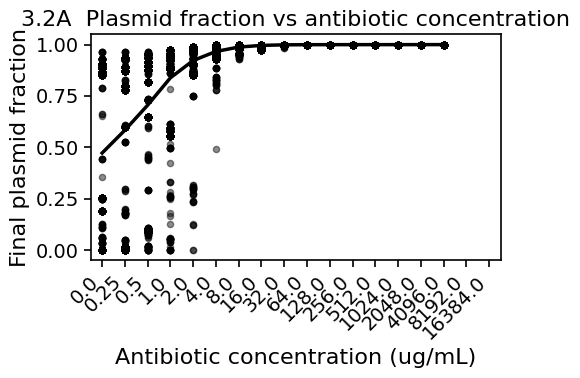

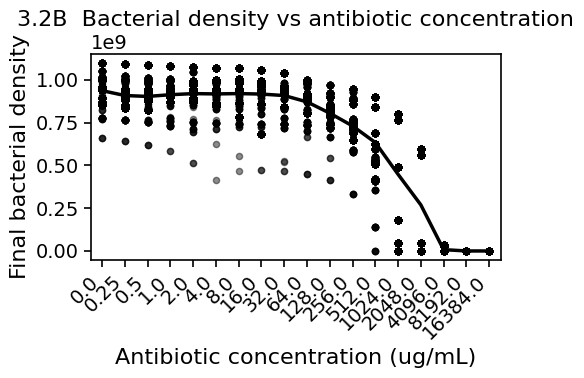

In [354]:
# Panel A: plasmid fraction vs antibiotic concentration

fig_A, ax_A = plot_metric_vs_antibiotic(
    exp32_AB_df,
    y_col="plasmid_fraction",
    ylabel="Final plasmid fraction",
    title="3.2A  Plasmid fraction vs antibiotic concentration",
    save_path=exp32_AB_fig_path / "exp32A_plasmid_fraction_vs_A.png",
    log_y=False,
)

# Panel B: bacterial density vs antibiotic concentration

fig_B, ax_B = plot_metric_vs_antibiotic(
    exp32_AB_df,
    y_col="bacterial_density",
    ylabel="Final bacterial density",
    title="3.2B  Bacterial density vs antibiotic concentration",
    save_path=exp32_AB_fig_path / "exp32B_bacterial_density_vs_A.png",
    log_y=False,
)


### Community-size scan at fixed antibiotic concentration

Community size is varied while the antibiotic concentration is held fixed. This tests whether increasing host diversity raises the probability that the plasmid persists in at least one favorable host background.


In [355]:
# 3.2C-D
# Vary community size M under a fixed antibiotic concentration.
#
# Incremental version:
# - Existing simulations are detected from the run directory.
# - Members are recovered from saved simulation metadata.
# - New random communities are added only if each M has fewer than the target number.
# - Existing simulations are loaded, not rerun.

import re
import pandas as pd
import numpy as np
from pathlib import Path

rng = np.random.default_rng(455)

M_values = list(range(1, len(random_pool) + 1))


exp32_CD_run_path = exp32_run_path / "CD_varyM_fixedA"
exp32_CD_run_path.mkdir(parents=True, exist_ok=True)

exp32_CD_fig_path = exp32_fig_path / "CD_varyM_fixedA"
exp32_CD_fig_path.mkdir(parents=True, exist_ok=True)

print("Amax =", Amax)
print("M_values =", M_values)
print("Target communities per size =", num_communities_per_size)
print("Run path =", exp32_CD_run_path)


Amax = 512.0
M_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Target communities per size = 100
Run path = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/experiment3_2_random_communities/CD_varyM_fixedA


In [356]:
# Scan existing simulation files and reconstruct existing communities.
#
# We use:
# filename -> M, rep, A
# metadata -> members

existing_files = sorted(exp32_CD_run_path.glob("exp32_CD_M*_rep*_A*.pkl.gz"))

pattern = re.compile(
    r"exp32_CD_M(?P<M>\d+)_rep(?P<rep>\d+)_A(?P<A0>.+)\.pkl\.gz"
)

existing_by_M = {M: {} for M in M_values}
existing_sets_by_M = {M: set() for M in M_values}

for file in existing_files:
    match = pattern.match(file.name)

    if match is None:
        continue

    M = int(match.group("M"))
    rep = int(match.group("rep"))

    if M not in existing_by_M:
        continue

    loaded = pn.load_simulation(file)

    members = loaded.metadata.get("members", None)
    if members is None:
        members = loaded.members

    members = tuple(sorted(members))

    existing_by_M[M][rep] = members
    existing_sets_by_M[M].add(members)

print("Existing simulation files:", len(existing_files))

for M in M_values:
    print(
        f"M={M:02d}: existing communities = {len(existing_by_M[M])}"
    )


Existing simulation files: 1741
M=01: existing communities = 20
M=02: existing communities = 100
M=03: existing communities = 100
M=04: existing communities = 100
M=05: existing communities = 100
M=06: existing communities = 100
M=07: existing communities = 100
M=08: existing communities = 100
M=09: existing communities = 100
M=10: existing communities = 100
M=11: existing communities = 100
M=12: existing communities = 100
M=13: existing communities = 100
M=14: existing communities = 100
M=15: existing communities = 100
M=16: existing communities = 100
M=17: existing communities = 100
M=18: existing communities = 100
M=19: existing communities = 20
M=20: existing communities = 1


In [357]:
# Add new random communities for each M until target number is reached.
#
# Safe version:
# - avoids infinite loops when num_communities_per_size exceeds possible combinations
# - caps the target for each M at comb(len(random_pool), M)
# - prints the effective target per M

from math import comb

community_design_by_M = {
    M: dict(existing_by_M[M])
    for M in M_values
}

new_communities_added = 0

n_pool = len(random_pool)

for M in M_values:
    n_possible = comb(n_pool, M)
    target_for_M = min(num_communities_per_size, n_possible)

    existing_reps = set(community_design_by_M[M].keys())

    print(
        f"M={M:02d} | possible={n_possible} | "
        f"target={target_for_M} | existing={len(community_design_by_M[M])}"
    )

    if len(community_design_by_M[M]) >= target_for_M:
        continue

    next_rep = 0
    attempts = 0
    max_attempts = 10000

    while len(community_design_by_M[M]) < target_for_M:
        attempts += 1

        if attempts > max_attempts:
            print(
                f"    stopping M={M:02d}: reached max attempts "
                f"({max_attempts}). Existing={len(community_design_by_M[M])}, "
                f"target={target_for_M}"
            )
            break

        while next_rep in existing_reps:
            next_rep += 1

        members = tuple(
            sorted(rng.choice(random_pool, size=M, replace=False).tolist())
        )

        if members in existing_sets_by_M[M]:
            continue

        community_design_by_M[M][next_rep] = members
        existing_sets_by_M[M].add(members)
        existing_reps.add(next_rep)

        print(f"    added M={M:02d}, rep={next_rep:03d}: {list(members)}")

        next_rep += 1
        new_communities_added += 1

print("New communities added:", new_communities_added)

total_sims = sum(len(community_design_by_M[M]) for M in M_values)

print("Total simulations expected after this run:", total_sims)
for M in M_values:
    print(f"M={M:02d}: total communities = {len(community_design_by_M[M])}")


M=01 | possible=20 | target=20 | existing=20
M=02 | possible=190 | target=100 | existing=100
M=03 | possible=1140 | target=100 | existing=100
M=04 | possible=4845 | target=100 | existing=100
M=05 | possible=15504 | target=100 | existing=100
M=06 | possible=38760 | target=100 | existing=100
M=07 | possible=77520 | target=100 | existing=100
M=08 | possible=125970 | target=100 | existing=100
M=09 | possible=167960 | target=100 | existing=100
M=10 | possible=184756 | target=100 | existing=100
M=11 | possible=167960 | target=100 | existing=100
M=12 | possible=125970 | target=100 | existing=100
M=13 | possible=77520 | target=100 | existing=100
M=14 | possible=38760 | target=100 | existing=100
M=15 | possible=15504 | target=100 | existing=100
M=16 | possible=4845 | target=100 | existing=100
M=17 | possible=1140 | target=100 | existing=100
M=18 | possible=190 | target=100 | existing=100
M=19 | possible=20 | target=20 | existing=20
M=20 | possible=1 | target=1 | existing=1
New communities added

In [358]:
# Run missing simulations across community sizes at fixed A.
#
# Incremental behavior:
# - If save_file exists, load.
# - If not, run -> save -> load.
# - Always rebuild summary from all available runs.

exp32_CD_rows = []

sim_counter = 0
run_counter = 0
skip_counter = 0

total_sims = sum(len(community_design_by_M[M]) for M in M_values)

for M in M_values:

    reps_for_M = sorted(community_design_by_M[M].keys())

    for rep in reps_for_M:

        members = list(community_design_by_M[M][rep])

        sim_counter += 1

        run_id = f"exp32_CD_M{M:02d}_rep{rep:03d}_A{Amax:g}"
        save_file = exp32_CD_run_path / f"{run_id}.pkl.gz"

        print(
            f"[{sim_counter:03d}/{total_sims:03d}] "
            f"M={M:02d} | rep={rep:03d} | A={Amax:g} | "
            f"members={members}"
        )

        if save_file.exists():
            print("    found saved simulation, loading...")
            loaded = pn.load_simulation(save_file)
            skip_counter += 1

        else:
            print("    saved simulation not found, running...")

            environment = pn.make_constant_environment(
                n_transfers=num_days,
                concentration=Amax,
            )

            result = pn.simulate_serial_transfers(
                model_params,
                members=members,
                environment=environment,
                config=experiment3_config,
                run_id=run_id,
                metadata={
                    "experiment": "3.2C-D",
                    "A0": Amax,
                    "n_members": M,
                    "rep": rep,
                    "members": members,
                },
            )

            pn.save_simulation(result, save_file)
            loaded = pn.load_simulation(save_file)
            run_counter += 1

        final_state = extract_final_community_state(
            loaded,
            density_extinction_threshold=experiment3_config.extinction_threshold,
        )

        exp32_CD_rows.append(
            {
                "run_id": run_id,
                "A0": Amax,
                "n_members": M,
                "rep": rep,
                "members": ";".join(members),
                "save_file": str(save_file),
                "plasmid_fraction": final_state["plasmid_frequency"],
                "bacterial_density": final_state["Btotal_final"],
                "Bp_final": final_state["Bp_final"],
                "Bempty_final": final_state["Bempty_final"],
            }
        )

        print(
            f"    result | "
            f"plasmid_fraction={final_state['plasmid_frequency']:.3f} | "
            f"bacterial_density={final_state['Btotal_final']:.3e} | "
            f"Bp={final_state['Bp_final']:.3e} | "
            f"Bempty={final_state['Bempty_final']:.3e}"
        )


exp32_CD_df = pd.DataFrame(exp32_CD_rows)
exp32_CD_df = exp32_CD_df.sort_values(
    ["n_members", "rep"]
).reset_index(drop=True)

summary_file = exp32_CD_run_path / "exp32_CD_summary.csv"
exp32_CD_df.to_csv(summary_file, index=False)

display(exp32_CD_df.head())

print("Summary rows:", len(exp32_CD_df))
print("New simulations run:", run_counter)
print("Saved simulations loaded:", skip_counter)
print("Saved summary table to:", summary_file)


Streaming output truncated to the last 5000 lines.
    found saved simulation, loading...
    result | plasmid_fraction=1.000 | bacterial_density=5.195e+08 | Bp=5.195e+08 | Bempty=0.000e+00
[076/1741] M=02 | rep=055 | A=512 | members=['C286', 'C290']
    found saved simulation, loading...
    result | plasmid_fraction=1.000 | bacterial_density=5.088e+08 | Bp=5.088e+08 | Bempty=0.000e+00
[077/1741] M=02 | rep=056 | A=512 | members=['C201', 'K112']
    found saved simulation, loading...
    result | plasmid_fraction=1.000 | bacterial_density=8.965e+08 | Bp=8.963e+08 | Bempty=2.428e+05
[078/1741] M=02 | rep=057 | A=512 | members=['C290', 'K209']
    found saved simulation, loading...
    result | plasmid_fraction=1.000 | bacterial_density=5.088e+08 | Bp=5.088e+08 | Bempty=0.000e+00
[079/1741] M=02 | rep=058 | A=512 | members=['K112', 'K216']
    found saved simulation, loading...
    result | plasmid_fraction=1.000 | bacterial_density=8.965e+08 | Bp=8.963e+08 | Bempty=2.428e+05
[080/1741]

,run_id,A0,n_members,rep,members,save_file,plasmid_fraction,bacterial_density,Bp_final,Bempty_final
0,exp32_CD_M01_rep000_A512,512.0,1,0,K209,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,NaN,0.000000e+00,0.000000e+00,0.000000
1,exp32_CD_M01_rep001_A512,512.0,1,1,C290,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,1.000000,5.087696e+08,5.087696e+08,0.000000
2,exp32_CD_M01_rep002_A512,512.0,1,2,K253,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,NaN,0.000000e+00,0.000000e+00,0.000000
3,exp32_CD_M01_rep003_A512,512.0,1,3,K213,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0.999602,8.405675e+08,8.402330e+08,334572.614021
4,exp32_CD_M01_rep004_A512,512.0,1,4,C002,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,NaN,0.000000e+00,0.000000e+00,0.000000


Summary rows: 1741
New simulations run: 0
Saved simulations loaded: 1741
Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T32/experiment3_2_random_communities/CD_varyM_fixedA/exp32_CD_summary.csv


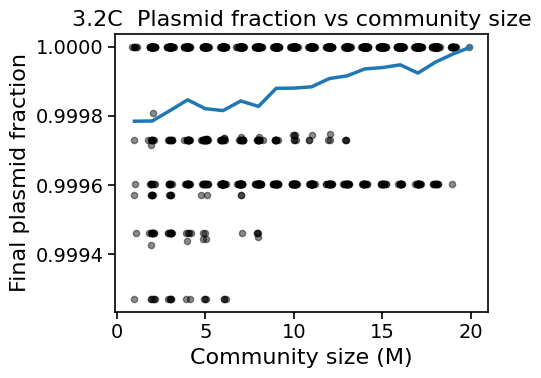

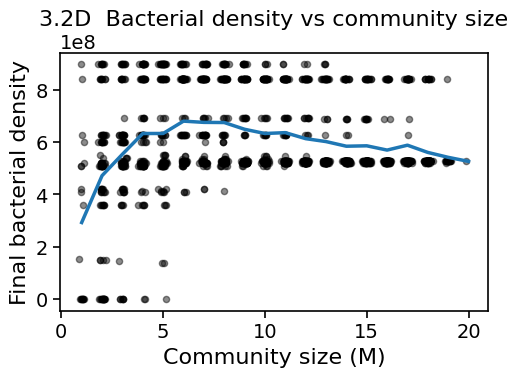

In [359]:
# Panel C: plasmid fraction vs community size

fig_C, ax_C = plot_metric_vs_community_size(
    exp32_CD_df,
    y_col="plasmid_fraction",
    ylabel="Final plasmid fraction",
    title="3.2C  Plasmid fraction vs community size",
    save_path=exp32_CD_fig_path / "exp32C_plasmid_fraction_vs_M.png",
    log_y=False,
)

# Panel D: bacterial density vs community size

fig_D, ax_D = plot_metric_vs_community_size(
    exp32_CD_df,
    y_col="bacterial_density",
    ylabel="Final bacterial density",
    title="3.2D  Bacterial density vs community size",
    save_path=exp32_CD_fig_path / "exp32D_bacterial_density_vs_M.png",
    log_y=False,
)
